# Khảo sát 5 dataset — House-Price Prediction

Notebook này phục vụ **khảo sát sơ bộ 5 dataset ứng viên** cho bài toán regression.

Mục tiêu:
- chạy đầy đủ `shape`, `head`, `info`, `describe`, missing, duplicate;
- xác định `target` giá;
- mô tả phân bố `target`, bao gồm skewness;
- đánh dấu potential outliers theo IQR;
- tạo **một bảng summary cho cả 5 dataset** để dùng trong report.

> Notebook này chưa làm sạch, encode, scale hay huấn luyện model.

In [1]:
# Cell nay: doc 5 file CSV cua 5 dataset ung vien vao dictionary dfs.
# pathlib: thu vien lam viec voi duong dan file/thu muc.
from pathlib import Path

# pandas: doc va xu ly du lieu dang bang.
import pandas as pd

# Duong dan toi thu muc data chua cac file CSV.
DATA_DIR = Path("../data")

# Dictionary anh xa ten dataset toi duong dan file.
datasets = {
    # Moi muc gom ten rut gon (data_1..data_5) va duong dan file tuong ung.
    "data_1": DATA_DIR / "data_public.csv",
    "data_2": DATA_DIR / "HN_Houseprice.csv",
    "data_3": DATA_DIR / "house_buying_dec29th_2025.csv",
    "data_4": DATA_DIR / "real_estate_listings.csv",
    "data_5": DATA_DIR / "sale_real_estate.csv",
}

# Doc tat ca file CSV thanh dictionary khoa=ten dataset, gia tri=DataFrame.
dfs = {name: pd.read_csv(path) for name, path in datasets.items()}

## 1. Xác định `target` giá

Tên cột giá có thể khác nhau giữa các nguồn dữ liệu. Notebook ưu tiên:
1. `TARGET_OVERRIDES` nếu bạn khai báo chính xác;
2. nếu chưa khai báo, tự dò theo các tên cột phổ biến như `Price`, `price`, `gia`, `selling_price`, `total_price`.

Nếu một dataset có nhiều cột giá và không thể xác định an toàn, notebook sẽ để `target = None` và in danh sách cột nghi ngờ để bạn chọn, thay vì tự đoán sai.

In [2]:
# Cell nay: tu dong xac dinh cot gia (target) cho tung dataset, uu tien ten khai bao thu cong.
# re: thu vien bieu thuc chinh quy, dung de chuan hoa ten cot.
import re

# unicodedata: xu ly Unicode, dung de bo dau tieng Viet trong ten cot.
import unicodedata

# display: hien thi bang trong notebook.
from IPython.display import display


# Ten hien thi dep cua tung dataset.
DISPLAY_NAMES = {
    "data_1": "HCM Real Estate — data_public",
    "data_2": "Hanoi House Price 2024",
    "data_3": "Vietnam Real Estate Catalyst",
    "data_4": "Vietnam Housing HCM",
    "data_5": "Real Estate in Vietnam",
}

# data_1 đã biết cột giá là "Price".
# Với các dataset còn lại, để None để notebook tự dò.
# Nếu notebook báo chưa xác định được, chỉ cần điền đúng tên cột tại đây.
# Khai bao thu cong cot gia neu biet chac; None de notebook tu do.
TARGET_OVERRIDES = {
    # data_1 da biet cot gia la Price; cac dataset con lai de notebook tu do.
    "data_1": "Price",
    "data_2": None,
    "data_3": None,
    "data_4": None,
    "data_5": None,
}

# Loai bai toan: regression (hoi quy) vi gia nha la bien lien tuc.
TASK_TYPE = "regression"


# Ham phu: chuan hoa ten cot - bo dau, viet thuong, xoa ky tu dac biet de de so sanh.
def _normalize_name(value: str) -> str:
    # NFKD: tach ky tu co dau thanh ky tu goc + dau rieng.
    text = unicodedata.normalize("NFKD", str(value))
    # Bo cac ky tu dau (combining) de con lai chu goc.
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    # Viet thuong va bo khoang trang dau/cuoi.
    text = text.lower().strip()
    # Xoa moi ky tu khong phai chu so/chu cai de so khop ten linh hoat.
    return re.sub(r"[^a-z0-9]+", "", text)


# Danh sach ten cot gia pho bien, uu tien theo thu tu.
PRICE_NAME_PRIORITY = [
    "price",
    "sellingprice",
    "saleprice",
    "houseprice",
    "totalprice",
    "propertyprice",
    "listingprice",
    "giaban",
    "gia",
    "pricevnd",
    "amount",
]


# Ham do cot gia: tra ve (ten cot gia tim duoc, danh sach cot nghi ngo).
def detect_price_target(df: pd.DataFrame) -> tuple[str | None, list[str]]:
    # Tao anh xa ten chuan hoa -> ten cot that.
    normalized = {_normalize_name(col): col for col in df.columns}

    # Duyet danh sach ten uu tien.
    for candidate in PRICE_NAME_PRIORITY:
        # Neu ten chuan hoa khop mot cot thi chon ngay.
        if candidate in normalized:
            # Tra ve cot gia chinh xac.
            return normalized[candidate], [normalized[candidate]]

    # possible: cac cot nghi ngo la gia (neu chua khop ten uu tien).
    possible = []
    # Duyet tung cot.
    for col in df.columns:
        # Chuan hoa ten cot.
        norm = _normalize_name(col)
        # Nhan dien cot gia qua tu khoa price/gia/giaban.
        if "price" in norm or norm.startswith("gia") or "giaban" in norm:
            # Them cot nghi ngo vao danh sach.
            possible.append(col)

    # Neu chi co dung 1 cot nghi ngo thi chon luon.
    if len(possible) == 1:
        # Tra ve cot duy nhat do.
        return possible[0], possible

    # Nếu có nhiều cột giá, ưu tiên giá tổng và tránh đơn giá/m2.
    # Neu co nhieu cot, loc bo cac cot don gia (gia/m2).
    non_unit = [
        col
        for col in possible
        # Dieu kien loc: loai cot chua tu khoa m2/sqm/unit price...
        if not any(
            # Cac tu khoa cho thay day la don gia, khong phai tong gia.
            token in _normalize_name(col)
            for token in ["m2", "sqm", "unitprice", "perm2", "persqm"]
        )
    ]

    # Neu chi con 1 cot tong gia thi chon cot do.
    if len(non_unit) == 1:
        # Tra ve cot tong gia.
        return non_unit[0], possible

    # Khong xac dinh chac chan: tra ve None kem danh sach cot nghi ngo de nguoi dung chon.
    return None, possible


# TARGETS: luu cot gia da xac dinh cho tung dataset.
TARGETS = {}
# Danh sach luu thong tin do target de hien thi.
target_audit_rows = []

# Duyet tung dataset.
for key, df in dfs.items():
    # Lay cot gia khai bao thu cong (neu co).
    override = TARGET_OVERRIDES.get(key)

    # Neu co khai bao thu cong...
    if override is not None:
        # ...kiem tra cot do co ton tai khong.
        if override not in df.columns:
            # Khong ton tai thi bao loi kem danh sach cot hien co.
            raise KeyError(
                f"{key}: TARGET_OVERRIDES={override!r} không tồn tại. "
                f"Các cột hiện có: {list(df.columns)}"
            )
        # Dung dung cot khai bao.
        target = override
        # Danh sach cot nghi ngo chi gom cot khai bao.
        possible = [override]
        # Ghi nguon xac dinh la khai bao thu cong.
        source = "override"
    # Khong co khai bao thi tu do.
    else:
        # Goi ham do cot gia.
        target, possible = detect_price_target(df)
        # Ghi nguon: tu dong hoac chua xac dinh.
        source = "auto" if target is not None else "chưa xác định"

    # Luu target cua dataset.
    TARGETS[key] = target
    # Luu dong audit: dataset, target, nguon, cot nghi ngo.
    target_audit_rows.append(
        {
            "Dataset": DISPLAY_NAMES[key],
            "Resolved target": target,
            "Nguồn": source,
            "Cột giá nghi ngờ": ", ".join(map(str, possible)) if possible else "",
        }
    )

# Tao bang audit.
target_audit = pd.DataFrame(target_audit_rows)
# Hien thi bang.
display(target_audit)

# Tim cac dataset chua xac dinh target.
unresolved = [key for key, target in TARGETS.items() if target is None]
# Neu co dataset chua xac dinh...
if unresolved:
    # In danh sach dataset can xu ly va huong dan dien TARGET_OVERRIDES.
    print(
        "\nCẦN XỬ LÝ:",
        ", ".join(unresolved),
        "chưa xác định chắc chắn target. "
        "Hãy xem cột nghi ngờ ở bảng trên rồi điền TARGET_OVERRIDES.",
    )
# Nguoc lai tat ca deu xac dinh duoc.
else:
    # In thong bao xac nhan.
    print("\nĐã xác định target cho cả 5 dataset.")

,Dataset,Resolved target,Nguồn,Cột giá nghi ngờ
0,HCM Real Estate — data_public,Price,override,Price
1,Hanoi House Price 2024,Price,auto,Price
2,Vietnam Real Estate Catalyst,price_million_vnd,auto,price_million_vnd
3,Vietnam Housing HCM,Price,auto,Price
4,Real Estate in Vietnam,price,auto,price



Đã xác định target cho cả 5 dataset.


## 2. Hàm inspection chi tiết

Với regression, phần phân tích `target` sử dụng:
- `describe()`;
- skewness;
- potential outliers.

Không dùng `value_counts()` làm phân bố chính cho giá nhà vì `target` là biến liên tục.

In [3]:
# Cell nay: dinh nghia ham phat hien outlier IQR va ham inspection chi tiet cho regression.
# numpy: tinh toan so hoc.
import numpy as np


# Ham danh dau outlier theo IQR - chi phan tich, khong xoa du lieu.
def _potential_outliers_iqr(df: pd.DataFrame, target: str | None = None) -> pd.DataFrame:
    # Chon cot so; .copy() tranh anh huong DataFrame goc.
    numeric = df.select_dtypes(include="number").copy()

    # Danh sach tich luy ket qua.
    rows = []
    # Duyet tung cot so.
    for col in numeric.columns:
        # Lay cot, bo gia tri thieu.
        s = numeric[col].dropna()

        # Bo cot rong hoac qua it gia tri khac nhau.
        if s.empty or s.nunique() < 4:
            # Chuyen sang cot tiep theo.
            continue

        # Q1: tu phan vi 25%.
        q1 = s.quantile(0.25)
        # Q3: tu phan vi 75%.
        q3 = s.quantile(0.75)
        # IQR: khoang tu phan vi.
        iqr = q3 - q1

        # IQR rong hoac bang 0 thi khong tinh duoc.
        if pd.isna(iqr) or iqr == 0:
            continue

        # Nguong duoi.
        lower = q1 - 1.5 * iqr
        # Nguong tren.
        upper = q3 + 1.5 * iqr
        # Dem gia tri ngoai khoang [lower, upper].
        count = int(((s < lower) | (s > upper)).sum())

        # Luu ket qua cot nay.
        rows.append(
            {
                "column": col,
                "lower_bound": lower,
                "upper_bound": upper,
                "potential_outliers": count,
                "percent": count / len(s) * 100,
                # Danh dau cot nay co phai target khong (uu tien hien thi target).
                "is_target": col == target,
            }
        )

    # Khong co cot nao thi tra DataFrame rong chuan.
    if not rows:
        return pd.DataFrame(
            columns=[
                "column",
                "lower_bound",
                "upper_bound",
                "potential_outliers",
                "percent",
                "is_target",
            ]
        )

    # Tra bang outlier: uu tien cot target, roi cot nhieu outlier nhat.
    return (
        pd.DataFrame(rows)
        .sort_values(["is_target", "potential_outliers"], ascending=[False, False])
        .reset_index(drop=True)
    )


# Ham inspection chinh cho mot dataset.
def inspect_dataset(
    name: str,
    df: pd.DataFrame,
    target: str | None,
    task_type: str = "regression",
) -> None:
    # In ten dataset.
    print(f"DATASET: {name}")
    # Duong ke phan cach.
    print("=" * 100)

    # Phan 1: kich thuoc.
    print("\n1. Shape")
    # (so dong, so cot).
    print(df.shape)

    # Phan 2: 10 dong dau.
    print("\n2. Head")
    # Hien thi 10 dong dau.
    display(df.head(10))

    # Phan 3: kieu du lieu.
    print("\n3. Data types / Info")
    # info(): kieu va so gia tri khong null tung cot.
    df.info()

    # Phan 3.1: bang kieu du lieu.
    print("\n3.1. Dtypes")
    # Kieu tung cot dang bang.
    display(df.dtypes.to_frame("dtype"))

    # Phan 4: thong ke mo ta.
    print("\n4. Descriptive statistics")
    # Thong ke mo ta tat ca cot.
    display(df.describe(include="all").T)

    # Phan 5: gia tri thieu.
    print("\n5. Missing values")
    # Dem o thieu theo cot.
    missing = df.isna().sum()
    # Bang so luong va % thieu.
    display(
        pd.DataFrame(
            {
                "missing_count": missing,
                # Phan tram o thieu.
                "missing_percent": missing / len(df) * 100,
            }
        )
    )

    # Phan 6: dong trung.
    print("\n6. Duplicated rows")
    # Dem dong trung.
    duplicate_count = int(df.duplicated().sum())
    # In so dong trung.
    print("Count:", duplicate_count)
    # In % dong trung.
    print("Percent:", duplicate_count / len(df) * 100)

    # Phan 7: phan tich target.
    print("\n7. Target analysis")
    # Chua xac dinh target thi bao va dung phan nay.
    if target is None:
        # In canh bao.
        print("Chưa xác định target cho dataset này.")
    # Da co target thi phan tich.
    else:
        # In ten target.
        print("Target:", target)
        # Thong ke mo ta target.
        display(df[target].describe().to_frame("value"))

        # Neu target la kieu so...
        if pd.api.types.is_numeric_dtype(df[target]):
            # ...in do lech (skewness) cua gia.
            print("Skewness:", df[target].skew())
        # Target khong phai kieu so...
        else:
            # In canh bao target chua phai kieu so.
            print(
                "CẢNH BÁO: target hiện không phải numeric dtype. "
                "Cần kiểm tra định dạng giá trước khi modeling."
            )

    # Phan 8: gia tri vo han.
    print("\n8. Infinite values trong numerical columns")
    # Cac cot so.
    numeric = df.select_dtypes(include="number")
    # Dem inf theo cot, sap giam dan.
    inf_count = np.isinf(numeric).sum().sort_values(ascending=False)
    # Hien thi bang inf.
    display(inf_count.to_frame("inf_count"))

    # Phan 9: outlier IQR.
    print("\n9. Potential outliers theo IQR")
    # Goi ham IQR va hien thi 20 cot dau.
    display(_potential_outliers_iqr(df, target=target).head(20))

## 3. Chạy inspection chi tiết cho cả 5 dataset

Output có thể dài và được giữ trong notebook làm bằng chứng.

In [4]:
# Cell nay: chay inspection cho ca 5 dataset.
# Duyet tung dataset.
for key, df in dfs.items():
    # Goi ham inspection.
    inspect_dataset(
        name=DISPLAY_NAMES[key],
        df=df,
        target=TARGETS[key],
        task_type=TASK_TYPE,
    )
    # Tach ket qua giua cac dataset.
    print("\n\n")

DATASET: HCM Real Estate — data_public

1. Shape
(51304, 28)

2. Head


,Title,Price,Area,Location,Listing ID,Last Updated,Property Type,Width,Length,Bedrooms,...,Longitude,VIP Account,Avatar,Agent Role,Agent Name,Agent Listing Count,Province,Property Type Slug,Scraped At,Last Updated Date
0,"🏠 NHÀ 3 TẦNG – TRUNG TÂM PHƯỚC LONG B, THỦ ĐỨC",7500.0,95.0,"Phường Phước Long,TP. Hồ Chí Minh",1546393.0,2 giờ trước,Nhà riêng,5.0,17.0,3.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
1,🔥🔥 NHÀ ĐẸP HIỆP BÌNH PHƯỚC – HẺM XE HƠI – KHU ...,4500.0,66.0,"đường Hiệp Bình,Phường Hiệp Bình Chánh,Quận Th...",1528310.0,2 giờ trước,Nhà riêng,4.0,NaN,2.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
2,🌟 HXH - NHÀ 3 TẦNG ĐẸP – TRUNG TÂM PHƯỚC LONG ...,7500.0,92.0,"Phường Phước Long B,Quận 9,TP. Hồ Chí Minh",1546519.0,2 giờ trước,Nhà riêng,5.0,17.0,3.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
3,🏡 HÀNG HIẾM LINH CHIỂU – NHÀ 2 TẦNG – VỊ TRÍ V...,4750.0,45.0,"đường số 19,Phường Linh Chiểu,Quận Thủ Đức,TP....",1544240.0,2 giờ trước,Nhà riêng,4.0,11.5,3.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
4,🚗 NHÀ ĐẸP HẺM XE HƠI – VỊ TRÍ VIP LINH TÂY – G...,4800.0,82.0,"đường số 9,Phường Linh Tây,Quận Thủ Đức,TP. Hồ...",1528291.0,2 giờ trước,Nhà riêng,8.5,NaN,2.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
5,🌟 ĐẤT DÂN CƯ LINH TRUNG – HẺM XE HƠI – 50M² – ...,4750.0,50.0,"Đường Số 8,Phường Linh Chiểu,Quận Thủ Đức,TP. ...",1545718.0,2 giờ trước,Nhà riêng,4.0,12.5,NaN,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
6,🏡 NHÀ 2 TẦNG TRƯỜNG THỌ – HẺM OTO 5M – GIÁ CHỈ...,3750.0,50.0,"Phường Trường Thọ,Quận Thủ Đức,TP. Hồ Chí Minh",1528299.0,2 giờ trước,Nhà riêng,4.2,NaN,2.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
7,🏠 CHÍNH CHỦ CẦN BÁN GẤP NHÀ TRUNG TÂM LINH CHI...,4500.0,110.0,"đường số 14,Phường Linh Chiểu,Quận Thủ Đức,TP....",1527178.0,2 giờ trước,Nhà riêng,5.0,NaN,2.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
8,Bán nhà 442m² ngang 11m giá 27.5 tỷ Phường An ...,27500.0,442.0,"Phường An Phú Đông,TP. Hồ Chí Minh(Mới)",1434745.0,11 giờ trước,Nhà riêng,11.0,40.0,19.0,...,106.688943,False,1,Môi giới,Lê Minh Cảnh,894.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:19,30/09/2025 07:24
9,🔥 NHÀ 2 TẦNG LINH TÂY – VỪA Ở VỪA CÓ THU NHẬP ...,6500.0,161.0,"Đường số 3,Phường Linh Tây,Quận Thủ Đức,TP. Hồ...",1548324.0,2 giờ trước,Nhà riêng,7.0,NaN,4.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:19,30/09/2025 16:24



3. Data types / Info
<class 'pandas.DataFrame'>
RangeIndex: 51304 entries, 0 to 51303
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                51304 non-null  str    
 1   Price                51304 non-null  float64
 2   Area                 51200 non-null  float64
 3   Location             51304 non-null  str    
 4   Listing ID           51304 non-null  float64
 5   Last Updated         51304 non-null  str    
 6   Property Type        51304 non-null  str    
 7   Width                34298 non-null  float64
 8   Length               25267 non-null  float64
 9   Bedrooms             16642 non-null  float64
 10  Bathrooms            10764 non-null  float64
 11  Floors               8680 non-null   float64
 12  Position             29432 non-null  str    
 13  Direction            10674 non-null  str    
 14  Alley Width          12253 non-null  float64
 15  Road Type            1416

,dtype
Title,str
Price,float64
Area,float64
Location,str
Listing ID,float64
Last Updated,str
Property Type,str
Width,float64
Length,float64
Bedrooms,float64



4. Descriptive statistics


...

,value
count,42257
unique,2511
top,Giá thỏa thuận
freq,4253


CẢNH BÁO: target hiện không phải numeric dtype. Cần kiểm tra định dạng giá trước khi modeling.

8. Infinite values trong numerical columns


,inf_count
product_id,0
bedrooms_num,0
bathrooms_num,0



9. Potential outliers theo IQR


,column,lower_bound,upper_bound,potential_outliers,percent,is_target
0,product_id,39372722.0,43750858.0,4400,10.412476,False
1,bedrooms_num,-4.5,7.5,1663,3.935443,False
2,bathrooms_num,-4.5,7.5,1406,3.327259,False


## 4. Bảng summary cho report

Bảng cuối tập trung vào:
- shape;
- missing;
- duplicate;
- `target`;
- min/median/max;
- skewness của giá.

Nếu `target` nào chưa xác định, bảng sẽ ghi `CHƯA XÁC ĐỊNH`.

In [5]:
# Cell nay: gom 5 dataset thanh bang summary gon cho bao cao.
# Ham tom tat mot dataset thanh mot dong.
def summarize_house_dataset(
    name: str,
    df: pd.DataFrame,
    target: str | None,
) -> dict:
    # Tao dictionary chua cac chi so chinh.
    row = {
        "Dataset": name,
        "Rows": len(df),
        "Raw attributes": df.shape[1],
        # Ten target; chua xac dinh thi ghi CHUA XAC DINH.
        "Target": target if target is not None else "CHƯA XÁC ĐỊNH",
        "Missing": int(df.isna().sum().sum()),
        "Duplicate": int(df.duplicated().sum()),
        "Duplicate rate (%)": round(df.duplicated().mean() * 100, 2),
        "Target min": None,
        "Target median": None,
        "Target max": None,
        # Cac o target chua tinh: de None, dien sau neu co target hop le.
        "Target skew": None,
    }

    # Neu target la cot so hop le thi tinh them thong ke gia.
    if target is not None and pd.api.types.is_numeric_dtype(df[target]):
        # Cap nhat them min/median/max/skew cua gia.
        row.update(
            {
                "Target min": df[target].min(),
                "Target median": df[target].median(),
                "Target max": df[target].max(),
                # skewness lam tron 3 chu so.
                "Target skew": round(float(df[target].skew()), 3),
            }
        )

    # Tra ve dong tom tat.
    return row


# Tao bang summary tu danh sach dataset.
house_summary = pd.DataFrame(
    [
        summarize_house_dataset(
            DISPLAY_NAMES[key],
            dfs[key],
            TARGETS[key],
        )
        for key in dfs
    ]
)

# Hien thi bang.
display(house_summary)

,Dataset,Rows,Raw attributes,Target,Missing,Duplicate,Duplicate rate (%),Target min,Target median,Target max,Target skew
0,HCM Real Estate — data_public,51304,28,Price,366518,0,0.00,0.0,7000.0,660000000.0,169.001
1,Hanoi House Price 2024,13535,15,Price,0,2656,19.62,NaN,NaN,NaN,NaN
2,Vietnam Real Estate Catalyst,66912,11,price_million_vnd,60315,0,0.00,0.0,7000.0,989000.0,13.102
3,Vietnam Housing HCM,26048,10,Price,94209,25037,96.12,NaN,NaN,NaN,NaN
4,Real Estate in Vietnam,42257,6,price,0,2264,5.36,NaN,NaN,NaN,NaN


# PART III - DATA CLEANING

Từ phần này trở đi notebook chỉ sử dụng **primary dataset `data_3` - Vietnam Real Estate Catalyst**.

Quy tắc chính:
- loại row thiếu hoặc không hợp lệ ở `target`;
- loại cột định danh / nội dung không phù hợp với tabular house-price model;
- chuẩn hóa `location`;
- chuyển các giá trị vật lý rõ ràng bất hợp lý thành missing thay vì tự bịa giá trị;
- missing feature được impute **sau khi chia train/validation/test**;
- outlier được phân tích, không xóa chỉ dựa trên IQR;
- target có độ lệch lớn nên model dùng `log1p(y)` trong `TransformedTargetRegressor`, sau đó chuyển dự đoán về đơn vị triệu VND.

In [6]:
# 3.1 Chọn primary dataset và thiết lập tái lập
# Cell nay: chon dataset chinh (data_3) va co dinh seed ngau nhien.
# json: doc/ghi file JSON.
import json

# random: sinh so ngau nhien (can co dinh seed).
import random

# sys: in phien ban Python.
import sys

# time: do thoi gian huan luyen.
import time

# pathlib: duong dan file.
from pathlib import Path

# joblib: luu/nap model.
import joblib

# matplotlib: ve bieu do.
import matplotlib.pyplot as plt

# numpy: tinh toan so hoc.
import numpy as np

# pandas: xu ly du lieu bang.
import pandas as pd

# scikit-learn: thu vien machine learning.
import sklearn

# Seed 42: tai lap ket qua.
RANDOM_SEED = 42
# Co dinh seed numpy.
np.random.seed(RANDOM_SEED)
# Co dinh seed Python random.
random.seed(RANDOM_SEED)

# Chon data_3 (Vietnam Real Estate Catalyst) lam dataset chinh.
PRIMARY_KEY = "data_3"
# Cot target: gia nha, don vi trieu VND.
TARGET = "price_million_vnd"

# Ban sao DataFrame dataset chinh.
house_raw = dfs[PRIMARY_KEY].copy()

# In ten dataset chinh.
print("Primary dataset:", DISPLAY_NAMES[PRIMARY_KEY])
# In kich thuoc du lieu tho.
print("Raw shape:", house_raw.shape)
# In ten target.
print("Target:", TARGET)
# In phien ban Python.
print("Python:", sys.version.split()[0])
# In phien ban pandas.
print("pandas:", pd.__version__)
# In phien ban numpy.
print("numpy:", np.__version__)
# In phien ban sklearn.
print("scikit-learn:", sklearn.__version__)

Primary dataset: Vietnam Real Estate Catalyst
Raw shape: (66912, 11)
Target: price_million_vnd
Python: 3.14.6
pandas: 3.0.3
numpy: 2.3.3
scikit-learn: 1.9.0


In [7]:
# 3.2 Audit missing, invalid values, extreme values
# Cell nay: ra soat missing, gia tri bat thuong va cuc tri cua cac cot quan trong.
# audit_columns: cac cot can kiem tra chi tiet.
audit_columns = [
    "timeline_hours",
    "area_m2",
    "bedrooms",
    "bathrooms",
    "floors",
    TARGET,
]

# In so dong trung.
print("Duplicate rows:", int(house_raw.duplicated().sum()))
# Tieu de phan missing.
print("\nMissing values:")
# Bang so luong va % missing tung cot.
display(
    pd.DataFrame(
        {
            "missing_count": house_raw.isna().sum(),
            # isna().mean(): ty le thieu trung binh moi cot.
            "missing_percent": house_raw.isna().mean().mul(100),
        }
    )
)

# Tieu de thong ke mo ta.
print("\nDescriptive statistics:")
# Thong ke mo ta cac cot quan trong.
display(house_raw[audit_columns].describe().T)

# Tieu de phan tu phan vi chi tiet.
print("\nDetailed quantiles:")
# Cac moc phan tram can xem, dac biet duoi phan phoi.
quantiles = [0, 0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.995, 0.999, 1.0]
# Tinh tu phan vi tai cac moc tren.
display(house_raw[audit_columns].quantile(quantiles).T)

# Tieu de phan dia diem pho bien.
print("\nTop locations:")
# Dem so listing theo location, hien thi 30 dia diem dau.
display(house_raw["location"].value_counts(dropna=False).head(30).to_frame("count"))

Duplicate rows: 0

Missing values:


,missing_count,missing_percent
id,0,0.000000
detail_url,7,0.010462
title,0,0.000000
location,0,0.000000
timeline_hours,0,0.000000
area_m2,16568,24.760880
bedrooms,11639,17.394488
bathrooms,15364,22.961502
floors,14634,21.870516
frontage,0,0.000000



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
timeline_hours,66912.0,8749.222666,6.863201e+03,2.0,3600.0,7200.0,8760.0,26280.0
area_m2,50344.0,1377.976700,2.763347e+05,1.0,42.0,60.0,92.0,62000000.0
bedrooms,55273.0,4.429649,4.500243e+00,1.0,3.0,4.0,5.0,127.0
bathrooms,51548.0,4.296617,4.618477e+00,1.0,2.0,3.0,5.0,127.0
floors,52278.0,14775.954379,3.377399e+06,0.0,3.0,4.0,6.0,772221339.0
price_million_vnd,64809.0,13810.677155,3.514473e+04,0.0,4600.0,7000.0,12800.0,989000.0



Detailed quantiles:


,0.000,0.001,0.010,0.050,0.500,0.950,0.990,0.995,0.999,1.000
timeline_hours,2.0,21.0,168.00,720.0,7200.0,26280.0,26280.0,26280.0,26280.0,26280.0
area_m2,1.0,2.0,18.00,30.0,60.0,237.0,955.7,2000.0,10000.0,62000000.0
bedrooms,1.0,1.0,1.00,2.0,4.0,10.0,22.0,30.0,50.0,127.0
bathrooms,1.0,1.0,1.00,1.0,3.0,10.0,23.0,30.0,50.0,127.0
floors,0.0,1.0,1.00,1.0,4.0,8.0,10.0,11.0,45.0,772221339.0
price_million_vnd,0.0,0.0,9.57,1500.0,7000.0,38500.0,130000.0,214480.0,510960.0,989000.0



Top locations:


,count
location,
"Gò Vấp, Hồ Chí Minh",3441
"Đống Đa, Hà Nội",3252
"Tân Phú, Hồ Chí Minh",3247
"Bình Tân, Hồ Chí Minh",3130
"Long Biên, Hà Nội",3111
"Quận 12, Hồ Chí Minh",2765
"Thanh Xuân, Hà Nội",2670
"Cầu Giấy, Hà Nội",2666
"Tân Bình, Hồ Chí Minh",2659


In [ ]:
# 3.3 Structural cleaning
# Cell nay: lam sach cau truc - xoa trung, loc target hop le, bo cot vo ich, chuan hoa location/frontage, kiem tra mien vat ly.
# Ban sao du lieu de lam sach.
house_clean = house_raw.copy()
# Nhat ky cac thao tac lam sach.
cleaning_log = []

# A. Exact duplicates
# A. Xoa dong trung - so dong truoc khi xoa.
rows_before = len(house_clean)
# Xoa dong trung hoan toan.
house_clean = house_clean.drop_duplicates().copy()
# Ghi log xoa trung.
cleaning_log.append(
    {
        "operation": "Remove exact duplicates",
        "affected_rows_or_cells": rows_before - len(house_clean),
        "reason": "Tránh lặp trọng số cho cùng một listing.",
    }
)

# B. Missing / invalid target
# B. Loc target - dem so dong thieu gia.
missing_target = int(house_clean[TARGET].isna().sum())
# Giu dong co gia (khong thieu).
house_clean = house_clean.loc[house_clean[TARGET].notna()].copy()

# Dem so dong co gia <= 0.
non_positive_target = int((house_clean[TARGET] <= 0).sum())
# Giu dong co gia duong.
house_clean = house_clean.loc[house_clean[TARGET] > 0].copy()

# Ghi log xoa dong thieu target.
# Ghi log xoa dong co gia khong duong.
cleaning_log.append(
    {
        "operation": "Remove missing target",
        "affected_rows_or_cells": missing_target,
        "reason": "Regression cần ground-truth price; không impute target.",
    }
)
cleaning_log.append(
    {
        "operation": "Remove non-positive target",
        "affected_rows_or_cells": non_positive_target,
        "reason": "Giá bán <= 0 không hợp lệ cho mục tiêu dự đoán giá.",
    }
)

# C. Drop irrelevant / identifier / free-text columns
# C. Cac cot vo ich can bo: dinh danh, free text, metadata listing.
IRRELEVANT_COLUMNS = ["id", "detail_url", "title", "timeline_hours"]
# Chi bo cac cot thuc su ton tai trong du lieu.
existing_irrelevant = [c for c in IRRELEVANT_COLUMNS if c in house_clean.columns]
# Xoa cac cot vo ich.
house_clean = house_clean.drop(columns=existing_irrelevant)

# Ghi log bo cot.
cleaning_log.append(
    {
        "operation": "Drop irrelevant columns",
        "affected_rows_or_cells": len(existing_irrelevant),
        "reason": "id/detail_url là định danh; title là free text; timeline_hours là metadata của listing, không phải thuộc tính căn nhà dùng cho form suy luận.",
    }
)

# D. Normalize location strings
# D. Chuan hoa chuoi location: bo khoang trang thua, gop nhieu khoang trang thanh 1.
house_clean["location"] = (
    # astype string + strip + replace khoang trang lap bang 1 khoang trang.
    house_clean["location"].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
)

# E. Convert frontage to stable binary representation
# E. Chuyen frontage ve kieu so nguyen co ho tro NaN (Int64).
house_clean["frontage"] = house_clean["frontage"].astype("Int64")

# F. Conservative physical sanity rules
# F. Mien gia tri vat ly hop ly cua tung cot so.
DOMAIN_BOUNDS = {
    "area_m2": (1, 1_000_000),
    "bedrooms": (0, 100),
    "bathrooms": (0, 100),
    "floors": (0, 100),
}

# Dict dem so o vi pham mien cua tung cot.
invalid_feature_counts = {}
# Duyet tung cot voi can duoi/can tren.
for col, (low, high) in DOMAIN_BOUNDS.items():
    # Danh dau gia tri ngoai [low, high].
    invalid_mask = house_clean[col].notna() & ~house_clean[col].between(low, high, inclusive="both")
    # Dem so o vi pham.
    invalid_feature_counts[col] = int(invalid_mask.sum())
    # Chuyen gia tri vi pham thanh NaN de impute sau.
    house_clean.loc[invalid_mask, col] = np.nan

# Ghi log ap dung mien vat ly.
cleaning_log.append(
    {
        "operation": "Apply conservative physical sanity bounds",
        "affected_rows_or_cells": int(sum(invalid_feature_counts.values())),
        "reason": "Các giá trị như hàng trăm triệu tầng/diện tích là lỗi parse rõ ràng; chuyển thành missing để impute trên train.",
    }
)

# Hien thi nhat ky lam sach.
display(pd.DataFrame(cleaning_log))
# In tieu de bang o vi pham.
print("Invalid feature cells converted to NaN:")
# Hien thi so o vi pham tung cot.
display(pd.Series(invalid_feature_counts, name="count").to_frame())
# In kich thuoc sau lam sach.
print("Clean shape:", house_clean.shape)


# Ham nho de luu DataFrame da lam sach xuong thu muc data.
def save_clean_dataframe(df: pd.DataFrame, filename: str = "house_price_clean.csv") -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    output_path = DATA_DIR / filename
    df.to_csv(output_path, index=False)
    return output_path


# Luu house_clean ra file CSV de cac lan sau co the doc lai tu disk.
HOUSE_PRICE_CLEAN_PATH = save_clean_dataframe(house_clean)
print("Saved clean data:", HOUSE_PRICE_CLEAN_PATH.resolve())


,operation,affected_rows_or_cells,reason
0,Remove exact duplicates,0,Tránh lặp trọng số cho cùng một listing.
1,Remove missing target,2103,Regression cần ground-truth price; không imput...
2,Remove non-positive target,362,Giá bán <= 0 không hợp lệ cho mục tiêu dự đoán...
3,Drop irrelevant columns,4,id/detail_url là định danh; title là free text...
4,Apply conservative physical sanity bounds,21,Các giá trị như hàng trăm triệu tầng/diện tích...


Invalid feature cells converted to NaN:


,count
area_m2,0
bedrooms,2
bathrooms,2
floors,17


Clean shape: (64447, 7)
Saved clean data: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\house_price\data\house_price_clean.csv


In [9]:
# 3.4 Before/After cleaning summary
# Cell nay: so sanh du lieu truoc va sau lam sach.
# Tao bang so sanh Before/After.
cleaning_summary = pd.DataFrame(
    {
        # Cot Metric: ten cac chi so.
        "Metric": [
            # So dong, so cot, dong trung, thieu target...
            "Rows",
            "Columns",
            "Duplicate rows",
            "Missing target",
            "Non-positive target",
            "Missing feature cells",
        ],
        # Cot Before: gia tri tinh tren du lieu tho (house_raw).
        "Before": [
            len(house_raw),
            house_raw.shape[1],
            int(house_raw.duplicated().sum()),
            # So dong thieu target truoc lam sach.
            int(house_raw[TARGET].isna().sum()),
            int((house_raw[TARGET].fillna(1) <= 0).sum()),
            int(house_raw.drop(columns=[TARGET]).isna().sum().sum()),
        ],
        # Cot After: gia tri tinh tren du lieu da lam sach (house_clean).
        "After structural cleaning": [
            len(house_clean),
            house_clean.shape[1],
            int(house_clean.duplicated().sum()),
            # So dong thieu target sau lam sach (phai bang 0).
            int(house_clean[TARGET].isna().sum()),
            int((house_clean[TARGET] <= 0).sum()),
            int(house_clean.drop(columns=[TARGET]).isna().sum().sum()),
        ],
    }
)
# Hien thi bang so sanh.
display(cleaning_summary)

# In tieu de phan missing con lai.
print("\nMissing values sau structural cleaning:")
# Dem missing theo cot, sap giam dan.
missing_after = house_clean.isna().sum().sort_values(ascending=False)
# Chi hien thi cot con thieu.
display(missing_after[missing_after > 0].to_frame("missing_count"))

# In tieu de phan kieu du lieu.
print("\nClean dtypes:")
# Hien thi kieu du lieu sau lam sach.
display(house_clean.dtypes.to_frame("dtype"))

,Metric,Before,After structural cleaning
0,Rows,66912,64447
1,Columns,11,7
2,Duplicate rows,0,6335
3,Missing target,2103,0
4,Non-positive target,362,0
5,Missing feature cells,58212,52694



Missing values sau structural cleaning:


,missing_count
area_m2,14492
floors,13978
bathrooms,13909
bedrooms,10315



Clean dtypes:


,dtype
location,string
area_m2,float64
bedrooms,float64
bathrooms,float64
floors,float64
frontage,Int64
price_million_vnd,float64


In [10]:
# 3.5 Outlier and skewness analysis - không xóa tự động bằng IQR
# Cell nay: phan tich outlier va skewness - khong xoa tu dong theo IQR.
# Ham bao cao outlier IQR cho danh sach cot.
def iqr_outlier_report(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    # Danh sach ket qua.
    rows = []
    # Duyet tung cot.
    for col in columns:
        # Lay cot, bo NaN.
        s = df[col].dropna()
        # Q1.
        q1 = s.quantile(0.25)
        # Q3.
        q3 = s.quantile(0.75)
        # IQR.
        iqr = q3 - q1
        # Nguong duoi.
        lower = q1 - 1.5 * iqr
        # Nguong tren.
        upper = q3 + 1.5 * iqr
        # Outlier tiem nang.
        mask = (s < lower) | (s > upper)
        # Luu bao cao cot.
        rows.append(
            {
                "column": col,
                "lower_bound": lower,
                "upper_bound": upper,
                "potential_outliers": int(mask.sum()),
                "percent": float(mask.mean() * 100),
                "min": s.min(),
                "max": s.max(),
                # Do lech phan phoi cua cot.
                "skew": s.skew(),
            }
        )
    return pd.DataFrame(rows)


# Cac cot so dua vao phan tich outlier.
HOUSE_NUMERIC_FOR_ANALYSIS = ["area_m2", "bedrooms", "bathrooms", "floors", TARGET]
# Goi ham bao cao.
house_outlier_report = iqr_outlier_report(house_clean, HOUSE_NUMERIC_FOR_ANALYSIS)
# Hien thi bang outlier.
display(house_outlier_report)

# In skewness cua gia goc.
print("Target skewness:", float(house_clean[TARGET].skew()))
# In skewness cua log1p(gia) - so sanh muc giam lech.
print("log1p(target) skewness:", float(np.log1p(house_clean[TARGET]).skew()))
# In quyet dinh: giu gia tri duong cua target, khong xoa theo IQR; dung log1p cho model.
print(
    "\nQuyết định: giữ các giá trị dương của target và dùng log1p trong mô hình. "
    "IQR dùng để mô tả outlier, không tự động loại mọi bất động sản giá cao."
)

,column,lower_bound,upper_bound,potential_outliers,percent,min,max,skew
0,area_m2,-33.0,167.0,4254,8.515664,1.0,500000.0,156.560899
1,bedrooms,0.0,8.0,3546,6.550654,1.0,100.0,8.716988
2,bathrooms,-2.5,9.5,2699,5.340536,1.0,100.0,8.488596
3,floors,-1.5,10.5,292,0.578573,0.0,100.0,12.993315
4,price_million_vnd,-7575.0,25025.0,5837,9.057055,1.0,989000.0,13.075795


Target skewness: 13.075795182175272
log1p(target) skewness: -1.7109750364605014

Quyết định: giữ các giá trị dương của target và dùng log1p trong mô hình. IQR dùng để mô tả outlier, không tự động loại mọi bất động sản giá cao.


# PART IV - DATA REPRESENTATION

House Price có:
- numerical features;
- categorical feature `location`;
- binary feature `frontage`.

Pipeline:
**Raw CSV -> clean DataFrame -> imputation -> scaling / one-hot encoding -> numerical matrix X**

Mọi transformer học statistic/category đều chỉ `fit` trên train.

In [11]:
# 4.1 Define X, y and feature groups
# Cell nay: tach X, y va nhom cac feature theo kieu du lieu.
# ColumnTransformer: ap pipeline khac nhau cho tung nhom cot.
from sklearn.compose import ColumnTransformer

# SimpleImputer: dien gia tri thieu.
from sklearn.impute import SimpleImputer

# Pipeline: chuoi cac buoc xu ly.
from sklearn.pipeline import Pipeline

# OneHotEncoder: bien cot phan loai thanh cot nhi phan; RobustScaler: chuan hoa ben vung voi outlier.
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# X: cac cot feature (bo target).
X = house_clean.drop(columns=[TARGET]).copy()
# y: cot gia, chuyen ve kieu float de hoi quy.
y = house_clean[TARGET].astype(float).copy()

# NUMERICAL_FEATURES: cac cot so.
NUMERICAL_FEATURES = ["area_m2", "bedrooms", "bathrooms", "floors"]
# CATEGORICAL_FEATURES: cot phan loai (ten dia diem).
CATEGORICAL_FEATURES = ["location"]
# BINARY_FEATURES: cot nhi phan (co mat tien hay khong).
BINARY_FEATURES = ["frontage"]

# Tao bang mo ta tung feature: ten va kieu ngu nghia.
semantic_feature_table = pd.DataFrame(
    [
        *({"feature": c, "semantic_type": "numerical"} for c in NUMERICAL_FEATURES),
        *({"feature": c, "semantic_type": "categorical nominal"} for c in CATEGORICAL_FEATURES),
        *({"feature": c, "semantic_type": "binary categorical"} for c in BINARY_FEATURES),
    ]
)
# Hien thi bang mo ta feature.
display(semantic_feature_table)

# In kich thuoc X.
print("X raw shape:", X.shape)
# In kich thuoc y.
print("y shape:", y.shape)
# In don vi cua target (trieu VND).
print("Target unit: million VND")

,feature,semantic_type
0,area_m2,numerical
1,bedrooms,numerical
2,bathrooms,numerical
3,floors,numerical
4,location,categorical nominal
5,frontage,binary categorical


X raw shape: (64447, 6)
y shape: (64447,)
Target unit: million VND


In [12]:
# 4.2 Define train-fitted preprocessing
# Cell nay: dinh nghia preprocessor - chi fit tren train.
# Ham tao OneHotEncoder tra ve mang dac (dense) de tuong thich moi phien ban sklearn.
def make_dense_onehot_encoder():
    # Compatible with both newer and older scikit-learn.
    # Thu truoc tham so sparse_output (phien ban moi).
    try:
        # OneHotEncoder: handle_unknown=ignore de khong loi khi gap location moi; sparse_output=False cho mang dac.
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    # Neu phien ban cu khong ho tro tham so tren...
    except TypeError:
        # ...dung tham so sparse (phien ban cu).
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


# Pipeline cot so: impute median (ben vung) + them cot danh dau missing, roi RobustScaler.
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", RobustScaler()),
    ]
)

# Pipeline cot phan loai: impute bang gia tri xuat hien nhieu nhat roi one-hot encode.
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_dense_onehot_encoder()),
    ]
)

# Pipeline cot nhi phan: chi impute bang mode (khong can scale).
binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

# Ghep 3 pipeline, moi pipeline ap cho nhom cot tuong ung.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERICAL_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ("binary", binary_pipeline, BINARY_FEATURES),
    ],
    # Bo cac cot khong thuoc nhom nao.
    remainder="drop",
    # Ten feature dau ra giu ten cot goc.
    verbose_feature_names_out=False,
)

# In thong bao preprocessor chi fit tren X_train.
print("Preprocessor defined. It will be fit ONLY on X_train.")

Preprocessor defined. It will be fit ONLY on X_train.


# PART V - EXPLORATORY DATA ANALYSIS

Tạo số liệu và biểu đồ đủ để giải thích:
- phân bố giá;
- skewness;
- quan hệ feature-target;
- correlation;
- outlier;
- khác biệt theo `location`.

,price_million_vnd
count,64447.000000
mean,13888.251985
std,35228.012947
min,1.000000
25%,4650.000000
50%,7100.000000
75%,12800.000000
max,989000.000000


Raw skewness: 13.075795182175272
log1p skewness: -1.7109750364605014


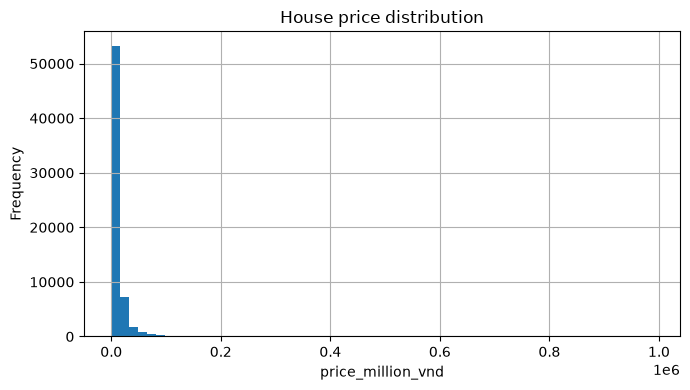

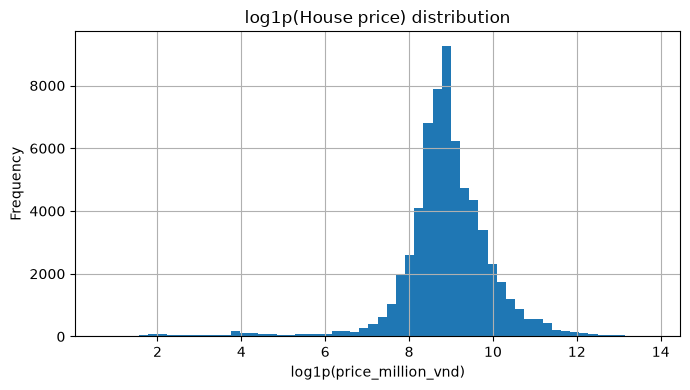

In [13]:
# 5.1 Target distribution: original and log1p
# Cell nay: phan tich phan bo cua gia (goc va log1p).
# Hien thi thong ke mo ta cua gia.
display(y.describe().to_frame("price_million_vnd"))
# In do lech cua gia goc.
print("Raw skewness:", float(y.skew()))
# In do lech sau log1p - thuong giam lech so voi gia goc.
print("log1p skewness:", float(np.log1p(y).skew()))

# Tao khung ve.
plt.figure(figsize=(7, 4))
# Bieu do tan suat cua gia goc (60 cot).
y.hist(bins=60)
# Tieu de.
plt.title("House price distribution")
# Nhan truc X.
plt.xlabel("price_million_vnd")
# Nhan truc Y.
plt.ylabel("Frequency")
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

# Tao khung ve thu hai.
plt.figure(figsize=(7, 4))
# Bieu do tan suat cua log1p(gia).
np.log1p(y).hist(bins=60)
# Tieu de.
plt.title("log1p(House price) distribution")
# Nhan truc X.
plt.xlabel("log1p(price_million_vnd)")
# Nhan truc Y.
plt.ylabel("Frequency")
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

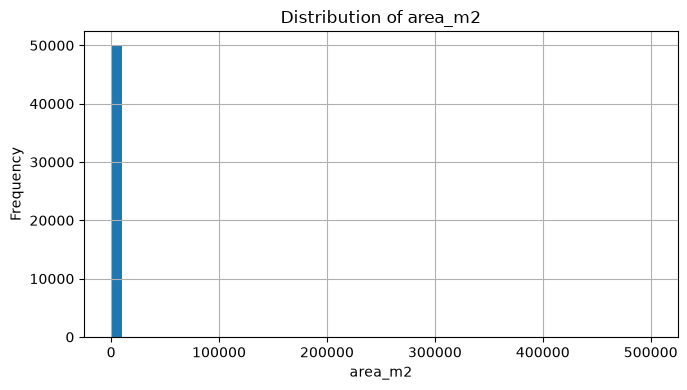

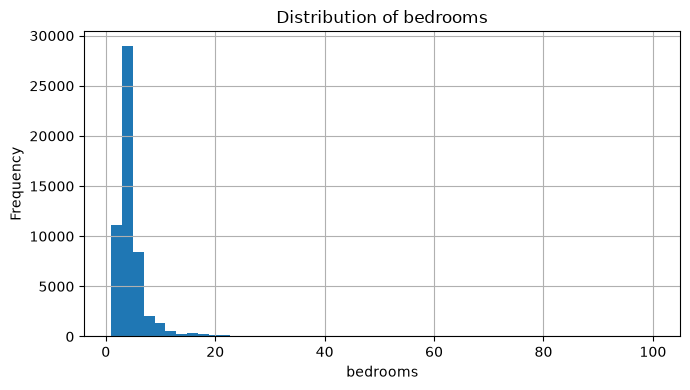

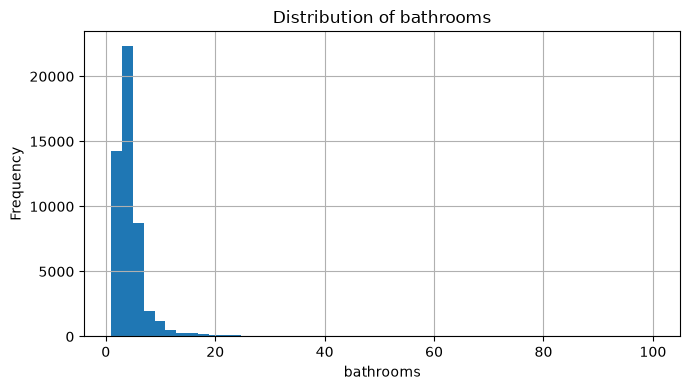

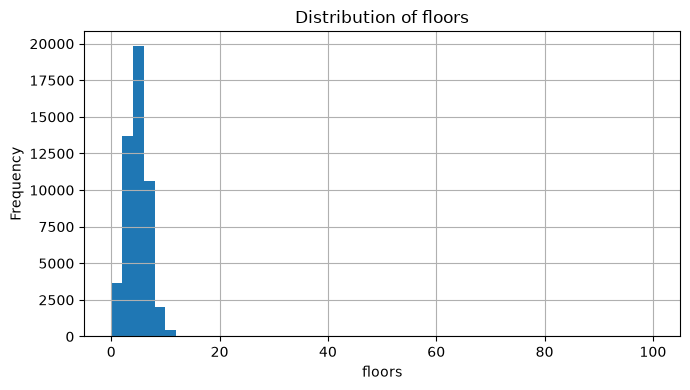

,count,mean,std,min,25%,50%,75%,max
area_m2,49955.0,145.719027,2560.699254,1.0,42.0,60.0,92.0,500000.0
bedrooms,54132.0,4.439093,4.476001,1.0,3.0,4.0,5.0,100.0
bathrooms,50538.0,4.304622,4.575585,1.0,2.0,3.0,5.0,100.0
floors,50469.0,4.409598,2.841381,0.0,3.0,4.0,6.0,100.0


In [14]:
# 5.2 Numerical feature distributions
# Cell nay: ve phan bo cac feature so.
# Vong lap ve bieu do cho tung cot so.
for col in NUMERICAL_FEATURES:
    # Tao khung ve.
    plt.figure(figsize=(7, 4))
    # Bieu do tan suat 50 cot; bo NaN truoc khi ve.
    house_clean[col].dropna().hist(bins=50)
    # Tieu de gom ten cot.
    plt.title(f"Distribution of {col}")
    # Truc X la ten cot.
    plt.xlabel(col)
    # Truc Y: tan suat.
    plt.ylabel("Frequency")
    # Dan bo cuc.
    plt.tight_layout()
    # Hien thi bieu do.
    plt.show()

# Bang thong ke mo ta cac feature so.
display(house_clean[NUMERICAL_FEATURES].describe().T)

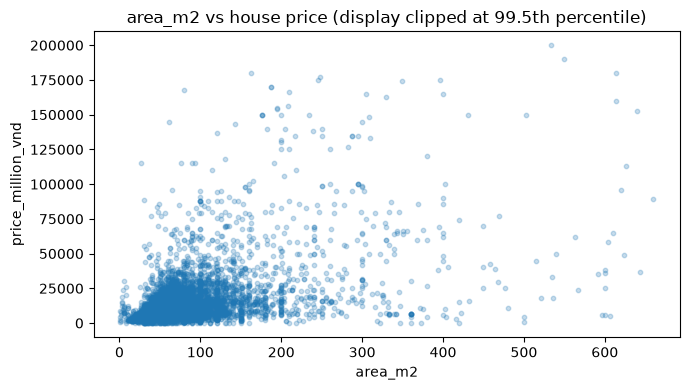

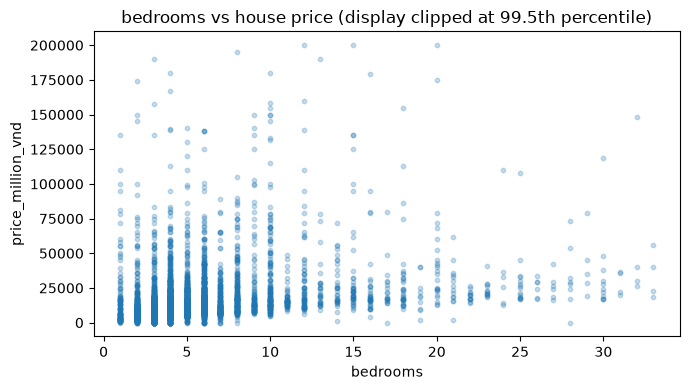

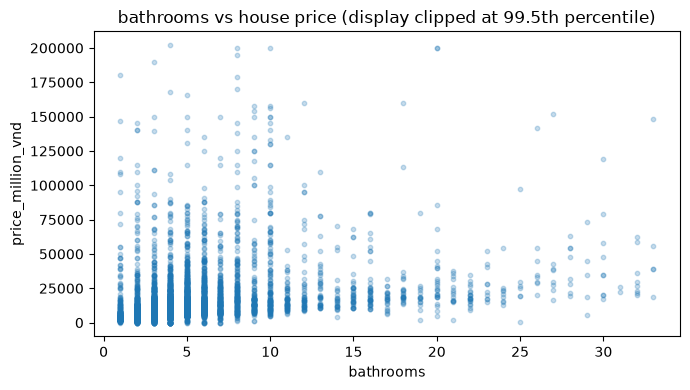

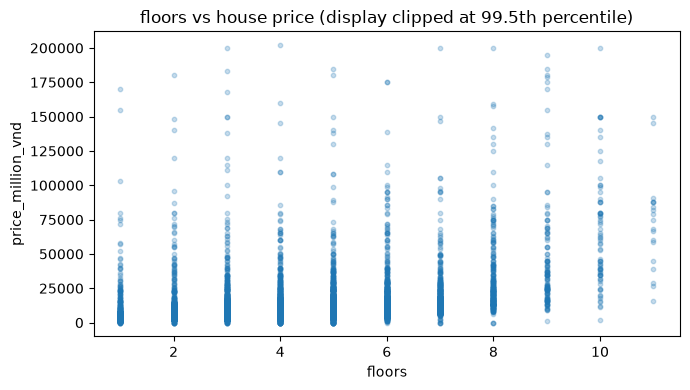

In [15]:
# 5.3 Feature-target scatter plots with display-only clipping for readability
# Cell nay: ve scatter feature vs gia - chi cat hien thi cho de nhin, khong doi du lieu.
# plot_df: du lieu dung de ve, bo NaN, khong thay doi du lieu goc.
plot_df = house_clean[NUMERICAL_FEATURES + [TARGET]].dropna().copy()

# Cap hien thi: moc 99.5% cua gia de loai diem cuc ky lon.
price_display_cap = plot_df[TARGET].quantile(0.995)

# Vong lap qua tung feature.
for col in ["area_m2", "bedrooms", "bathrooms", "floors"]:
    # Cap hien thi rieng cho tung feature.
    feature_display_cap = plot_df[col].quantile(0.995)
    # Chi giu cac dong nam duoi ca 2 cap de bieu do khong bi diem cuc lon lam mat hinh.
    view = plot_df[(plot_df[TARGET] <= price_display_cap) & (plot_df[col] <= feature_display_cap)]

    # Neu con qua nhieu diem...
    if len(view) > 10000:
        # ...lay ngau nhien 10000 dong de ve nhanh, co dinh seed.
        view = view.sample(10000, random_state=RANDOM_SEED)

    # Tao khung ve.
    plt.figure(figsize=(7, 4))
    # Ve scatter: truc X la feature, truc Y la gia; alpha va s lam diem trong nho.
    plt.scatter(view[col], view[TARGET], alpha=0.25, s=10)
    # Tieu de ghi ro chi cat hien thi.
    plt.title(f"{col} vs house price (display clipped at 99.5th percentile)")
    # Nhan truc X.
    plt.xlabel(col)
    # Nhan truc Y.
    plt.ylabel("price_million_vnd")
    # Dan bo cuc.
    plt.tight_layout()
    # Hien thi bieu do.
    plt.show()

,correlation_with_price
bathrooms,0.279569
bedrooms,0.275004
floors,0.160374
frontage,0.146747
area_m2,0.070485


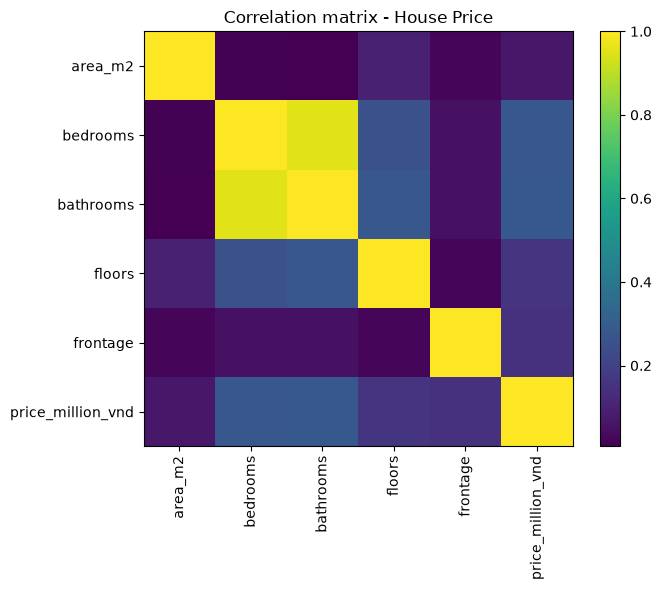

In [16]:
# 5.4 Correlation analysis
# Cell nay: ma tran tuong quan giua feature so va gia.
# Tinh tuong quan Pearson cho cac cot so + target.
numeric_corr = house_clean[NUMERICAL_FEATURES + BINARY_FEATURES + [TARGET]].corr(numeric_only=True)

# Hien thi bang tuong quan voi gia, sap theo tri tuyet doi giam dan.
display(
    numeric_corr[TARGET]
    # Bo cot target khoi danh sach.
    .drop(TARGET)
    # Sap giam dan theo tri tuyet doi.
    .sort_values(key=lambda s: s.abs(), ascending=False)
    # Dua thanh bang 1 cot.
    .to_frame("correlation_with_price")
)

# Tao khung ve.
plt.figure(figsize=(7, 6))
# Hien thi ma tran duoi dang anh mau.
plt.imshow(numeric_corr, aspect="auto")
# Thanh mau chu thich.
plt.colorbar()
# Nhan cot truc X.
plt.xticks(range(len(numeric_corr.columns)), numeric_corr.columns, rotation=90)
# Nhan hang truc Y.
plt.yticks(range(len(numeric_corr.index)), numeric_corr.index)
# Tieu de.
plt.title("Correlation matrix - House Price")
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

,count,median,mean
location,,,
"Hoàn Kiếm, Hà Nội",267,37000.0,94146.041199
"Quận 1, Hồ Chí Minh",740,21500.0,41419.260811
"Quận 5, Hồ Chí Minh",374,15700.0,23898.780749
"Cầu Giấy, Hà Nội",2605,13000.0,21134.449758
"Tây Hồ, Hà Nội",1349,13000.0,30789.005337
"Quận 2, Hồ Chí Minh",615,11599.0,26081.527285
"Quận 3, Hồ Chí Minh",572,10900.0,28366.318007
"Đống Đa, Hà Nội",3127,10500.0,17967.721266
"Ba Đình, Hà Nội",1364,10000.0,23436.749707


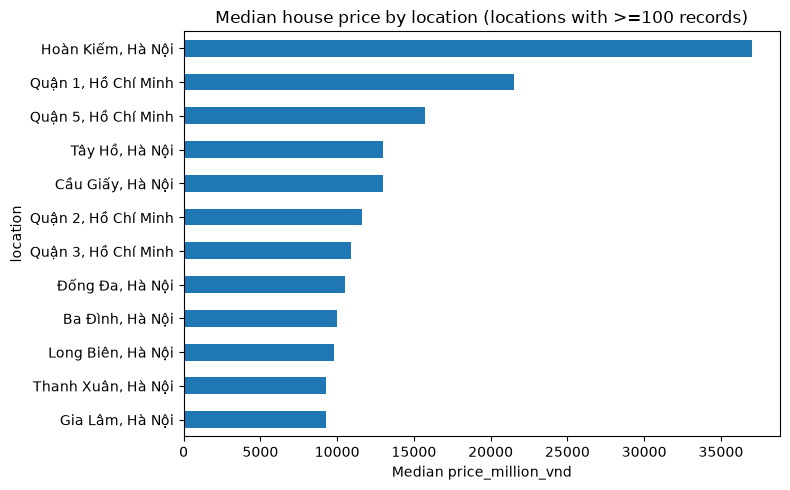

In [17]:
# 5.5 Location analysis
# Cell nay: phan tich gia theo location.
# Tinh count/median/mean cua gia theo tung location.
location_stats = (
    house_clean.groupby("location")[TARGET]
    # Tinh 3 chi so: so listing, gia trung vi, gia trung binh.
    .agg(["count", "median", "mean"])
    # Chi giu location co it nhat 100 listing de thong ke on dinh.
    .query("count >= 100")
    # Sap theo gia trung vi giam dan.
    .sort_values("median", ascending=False)
)

# Hien thi 20 location cao nhat.
display(location_stats.head(20))

# Lay 12 location dau va sap tang dan de ve ngang.
top_locations = location_stats.head(12).sort_values("median")
# Tao khung ve.
plt.figure(figsize=(8, 5))
# Ve bieu do ngang gia trung vi theo location.
top_locations["median"].plot(kind="barh")
# Tieu de.
plt.title("Median house price by location (locations with >=100 records)")
# Nhan truc X.
plt.xlabel("Median price_million_vnd")
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

# PART VI - TRAIN, VALIDATION, AND TEST DATA

Sử dụng 70% train, 15% validation, 15% test.

Không fit imputer/scaler/encoder trên toàn dataset. Validation/test chỉ được `transform` bằng preprocessing đã học từ train.

In [18]:
# 6.1 Split 70/15/15
# Cell nay: chia du lieu 70% train, 15% validation, 15% test.
# Ham chia du lieu ngau nhien.
from sklearn.model_selection import train_test_split

# Chia lan 1: 70% train, 30% tam.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    # 30% giu lai cho lan chia thu hai.
    test_size=0.30,
    # Co dinh seed.
    random_state=RANDOM_SEED,
)

# Chia lan 2: phan tam thanh validation va test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    # 50% phan tam = 15% tong du lieu lam test.
    test_size=0.50,
    # Co dinh seed.
    random_state=RANDOM_SEED,
)


# Ham tinh thong ke cua target cho tung tap.
def target_split_stats(name, target_series):
    # Tra ve dictionary: ten tap, so dong, mean, median, std, skew.
    return {
        "split": name,
        "rows": len(target_series),
        "mean": target_series.mean(),
        "median": target_series.median(),
        "std": target_series.std(),
        "skew": target_series.skew(),
    }


# Tao bang so sanh thong ke target giua 3 tap.
split_summary = pd.DataFrame(
    [
        target_split_stats("train", y_train),
        target_split_stats("validation", y_val),
        target_split_stats("test", y_test),
    ]
)
# Hien thi bang.
display(split_summary)

,split,rows,mean,median,std,skew
0,train,45112,13805.968647,7100.0,34249.330491,12.809374
1,validation,9667,14339.721222,7100.0,38792.191594,12.591728
2,test,9668,13820.772968,7200.0,35979.714792,14.479244


In [19]:
# 6.2 Fit representation ONLY on train and report exact input shape
# Cell nay: fit preprocessing tren train roi transform ca 3 tap de ghi nhan shape.
# clone: ban sao chua fit cua preprocessor.
from sklearn.base import clone

# Sao chep preprocessor de fit rieng.
representation_preprocessor = clone(preprocessor)
# Fit tren train: hoc imputer, scaler, encoder.
representation_preprocessor.fit(X_train, y_train)

# Bien doi train thanh ma tran so.
X_train_num = representation_preprocessor.transform(X_train)
# Transform validation bang preprocessor da fit tren train.
X_val_num = representation_preprocessor.transform(X_val)
# Transform test - khong hoc lai, tranh data leakage.
X_test_num = representation_preprocessor.transform(X_test)

# Ten feature sau bien doi.
feature_names = representation_preprocessor.get_feature_names_out()

# Bang so sanh shape tho va shape dau vao model.
representation_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "raw_shape": [X_train.shape, X_val.shape, X_test.shape],
        "model_input_shape": [X_train_num.shape, X_val_num.shape, X_test_num.shape],
        "dtype": [
            str(X_train_num.dtype),
            str(X_val_num.dtype),
            str(X_test_num.dtype),
        ],
    }
)
# Hien thi bang.
display(representation_summary)

# In so chieu feature.
print("Final feature dimension d =", len(feature_names))
# In tieu de 40 feature dau.
print("First 40 transformed feature names:")
# In 40 ten feature dau (one-hot location tao nhieu cot).
print(feature_names[:40].tolist())

# In tieu de: mot dong tho.
print("\nOne raw observation:")
# Hien thi dong dau tien X_train.
display(X_train.head(1))

# In tieu de: vector so sau bien doi.
print("\nCorresponding numerical feature vector:")
# Dong dau tien cua ma tran da bien doi, chuyen thanh mang 1 chieu.
first_vector = np.asarray(X_train_num[0]).reshape(-1)
# Hien thi tung feature va gia tri so (gioi han 80 dong cho gon).
display(pd.DataFrame({"feature": feature_names, "value": first_vector}).head(80))

,split,raw_shape,model_input_shape,dtype
0,train,"(45112, 6)","(45112, 259)",float64
1,validation,"(9667, 6)","(9667, 259)",float64
2,test,"(9668, 6)","(9668, 259)",float64


Final feature dimension d = 259
First 40 transformed feature names:
['area_m2', 'bedrooms', 'bathrooms', 'floors', 'missingindicator_area_m2', 'missingindicator_bedrooms', 'missingindicator_bathrooms', 'missingindicator_floors', 'location_An Dương, Hải Phòng', 'location_An Lão, Hải Phòng', 'location_Ba Vì, Hà Nội', 'location_Ba Đình, Hà Nội', 'location_Biên Hòa, Đồng Nai', 'location_Buôn Ma Thuột, Đắk Lắk', 'location_Bà Rịa, Bà Rịa Vũng Tàu', 'location_Bàu Bàng, Bình Dương', 'location_Bình Chánh, Hồ Chí Minh', 'location_Bình Long, Bình Phước', 'location_Bình Lục, Hà Nam', 'location_Bình Minh, Vĩnh Long', 'location_Bình Thạnh, Hồ Chí Minh', 'location_Bình Thủy, Cần Thơ', 'location_Bình Tân, Hồ Chí Minh', 'location_Bù Đăng, Bình Phước', 'location_Bảo Lâm, Lâm Đồng', 'location_Bảo Lộc, Lâm Đồng', 'location_Bắc Giang, Bắc Giang', 'location_Bắc Ninh, Bắc Ninh', 'location_Bắc Tân Uyên, Bình Dương', 'location_Bắc Từ Liêm, Hà Nội', 'location_Bến Cát, Bình Dương', 'location_Bến Lức, Long An', '

,location,area_m2,bedrooms,bathrooms,floors,frontage
4277,"Bình Thạnh, Hồ Chí Minh",30.0,6.0,2.0,3.0,0



Corresponding numerical feature vector:


,feature,value
0,area_m2,-0.9375
1,bedrooms,2.0000
2,bathrooms,-1.0000
3,floors,-0.5000
4,missingindicator_area_m2,0.0000
...,...,...
75,"location_Hàm Thuận Nam, Bình Thuận",0.0000
76,"location_Hòa Vang, Đà Nẵng",0.0000
77,"location_Hóc Môn, Hồ Chí Minh",0.0000
78,"location_Hương Sơn, Hà Tĩnh",0.0000


In [20]:
# Part IV evidence — Raw representation -> Clean representation

sample_index = X_train.index[0]

print("RAW REPRESENTATION")
display(house_raw.loc[[sample_index]])

print("\nCLEAN REPRESENTATION")
display(house_clean.loc[[sample_index]])

print("\nMODEL FEATURES BEFORE NUMERICAL TRANSFORMATION")
display(X_train.loc[[sample_index]])

RAW REPRESENTATION


,id,detail_url,title,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
4277,131700,https://batdongsan.vn/ban-nha-nguyen-van-dau-2...,BÁN NHÀ NGUYỄN VĂN ĐẬU – 2 TẦNG – GẦN HẼM XE T...,"Bình Thạnh, Hồ Chí Minh",8760,30.0,6.0,2.0,3.0,False,4580.0



CLEAN REPRESENTATION


,location,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
4277,"Bình Thạnh, Hồ Chí Minh",30.0,6.0,2.0,3.0,0,4580.0



MODEL FEATURES BEFORE NUMERICAL TRANSFORMATION


,location,area_m2,bedrooms,bathrooms,floors,frontage
4277,"Bình Thạnh, Hồ Chí Minh",30.0,6.0,2.0,3.0,0


In [21]:
preview_cols = list(feature_names[:12])

location_cols = [col for col in feature_names if "location" in col][:8]

selected_cols = list(dict.fromkeys(preview_cols + location_cols))

X_train_matrix_preview = pd.DataFrame(
    np.asarray(X_train_num[:5]),
    columns=feature_names,
    index=X_train.index[:5],
)

display(X_train_matrix_preview[selected_cols])

,area_m2,bedrooms,bathrooms,floors,missingindicator_area_m2,missingindicator_bedrooms,missingindicator_bathrooms,missingindicator_floors,"location_An Dương, Hải Phòng","location_An Lão, Hải Phòng","location_Ba Vì, Hà Nội","location_Ba Đình, Hà Nội","location_Biên Hòa, Đồng Nai","location_Buôn Ma Thuột, Đắk Lắk","location_Bà Rịa, Bà Rịa Vũng Tàu","location_Bàu Bàng, Bình Dương"
4277,-0.9375,2.0,-1.0,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
64233,-0.3750,-2.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14421,0.0000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65109,-0.6875,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65865,2.0625,6.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Part IV evidence — One-hot encoding for location

location_encoder = representation_preprocessor.named_transformers_["categorical"].named_steps[
    "onehot"
]

location_categories = location_encoder.categories_[0]

print("Number of learned location categories:", len(location_categories))
print("First 20 categories:")
print(location_categories[:20])

Number of learned location categories: 250
First 20 categories:
['An Dương, Hải Phòng' 'An Lão, Hải Phòng' 'Ba Vì, Hà Nội'
 'Ba Đình, Hà Nội' 'Biên Hòa, Đồng Nai' 'Buôn Ma Thuột, Đắk Lắk'
 'Bà Rịa, Bà Rịa Vũng Tàu' 'Bàu Bàng, Bình Dương'
 'Bình Chánh, Hồ Chí Minh' 'Bình Long, Bình Phước' 'Bình Lục, Hà Nam'
 'Bình Minh, Vĩnh Long' 'Bình Thạnh, Hồ Chí Minh' 'Bình Thủy, Cần Thơ'
 'Bình Tân, Hồ Chí Minh' 'Bù Đăng, Bình Phước' 'Bảo Lâm, Lâm Đồng'
 'Bảo Lộc, Lâm Đồng' 'Bắc Giang, Bắc Giang' 'Bắc Ninh, Bắc Ninh']


In [23]:
sample_location = X_train["location"].iloc[0]

print("Raw categorical value:")
print(sample_location)

location_feature_names = [name for name in feature_names if "location" in name]

sample_transformed = pd.DataFrame(
    np.asarray(X_train_num[:1]),
    columns=feature_names,
)

active_location_features = sample_transformed[location_feature_names].T

active_location_features = active_location_features[active_location_features.iloc[:, 0] != 0]

print("\nActive one-hot location feature:")
display(active_location_features)

Raw categorical value:
Bình Thạnh, Hồ Chí Minh

Active one-hot location feature:


,0
"location_Bình Thạnh, Hồ Chí Minh",1.0


In [24]:
# 6.3 Model-input numerical range
# Cell nay: kiem tra dai gia tri dau vao model.
# Chuyen ma tran train thanh mang numpy.
train_array = np.asarray(X_train_num)
# In kieu du lieu cua ma tran.
print("Model input dtype:", train_array.dtype)
# Gia tri nho nhat.
print("Train min:", float(np.nanmin(train_array)))
# Gia tri lon nhat.
print("Train max:", float(np.nanmax(train_array)))
# Trung binh.
print("Train mean:", float(np.nanmean(train_array)))
# Do lech chuan.
print("Train std:", float(np.nanstd(train_array)))
# In khang dinh validation/test chi dung preprocessing fit tren train.
print("Validation/test were transformed using TRAIN-fitted preprocessing only.")

Model input dtype: float64
Train min: -3.0
Train max: 15623.125
Train mean: 0.02249863659798932
Train std: 5.14973657583327
Validation/test were transformed using TRAIN-fitted preprocessing only.


# PART VII - MODEL DEVELOPMENT

So sánh 5 mô hình hồi quy:
1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor

Do `price_million_vnd` lệch phải mạnh, tất cả mô hình dùng `TransformedTargetRegressor`:
- học trên `log1p(y)`;
- dự đoán được `expm1()` về lại đơn vị triệu VND;
- metric vẫn tính trên thang giá gốc.

In [25]:
# 7.1 Define regression models and metrics
# Cell nay: dinh nghia 5 mo hinh hoi quy, metrics va ham tao estimator.
# TransformedTargetRegressor: bọc mo hinh de bien doi target (log1p) khi fit va expm1 khi du doan.
from sklearn.compose import TransformedTargetRegressor

# LinearRegression: hoi quy tuyen tinh; Ridge: tuyen tinh co dieu chinh L2.
from sklearn.linear_model import LinearRegression, Ridge

# DecisionTreeRegressor: cay quyet dinh cho hoi quy.
from sklearn.tree import DecisionTreeRegressor

# RandomForest: rung ngau nhien; GradientBoosting: tang cuong gradient.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Cac ham tinh MAE, MSE, R2.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# REGRESSORS: dictionary 5 mo hinh hoi quy.
REGRESSORS = {
    # Linear Regression: mo hinh co ban nhat.
    "Linear Regression": LinearRegression(),
    # Ridge: alpha=1.0 muc do chinh quy hoa.
    "Ridge Regression": Ridge(alpha=1.0),
    # Decision Tree: min_samples_leaf=5 tranh overfit.
    "Decision Tree": DecisionTreeRegressor(
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
    ),
    # Random Forest: 150 cay, min_samples_leaf=2, dung moi CPU.
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    # Gradient Boosting: 150 cay nho, learning_rate 0.05, max_depth=3.
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_SEED,
    ),
}


# Ham tinh cac metrics hoi quy.
def regression_scores(y_true, y_pred):
    # MAE: sai so tuyet doi trung binh.
    mae = mean_absolute_error(y_true, y_pred)
    # MSE: binh phuong sai so trung binh.
    mse = mean_squared_error(y_true, y_pred)
    # RMSE: can bac hai cua MSE, cung don vi voi gia.
    rmse = float(np.sqrt(mse))
    # R2: ty le bien thien duoc giai thich.
    r2 = r2_score(y_true, y_pred)
    # Tra ve dictionary 4 metrics.
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    }


# Ham tao estimator hoi quy hoan chinh: preprocessor + model + bien doi target log1p/expm1.
def make_regression_estimator(base_regressor):
    # Pipeline ben trong: preprocessor roi model.
    regression_pipeline = Pipeline(
        steps=[
            # Buoc 1: preprocessor.
            ("preprocessor", clone(preprocessor)),
            # Buoc 2: mo hinh hoi quy.
            ("model", clone(base_regressor)),
        ]
    )
    # Boc pipeline vao TransformedTargetRegressor.
    return TransformedTargetRegressor(
        # regressor: pipeline se duoc fit/predict.
        regressor=regression_pipeline,
        # func: bien doi target thanh log1p(y) truoc khi huan luyen (giam lech phai).
        func=np.log1p,
        # inverse_func: chuyen du doan ve lai don vi trieu VND.
        inverse_func=np.expm1,
        # Tat kiem tra inverse de tranh loi lam tron so.
        check_inverse=False,
    )

In [26]:
# 7.2 Train on train; evaluate on validation
# Cell nay: huan luyen 5 mo hinh tren train va danh gia tren validation.
# Luu estimator da fit.
fitted_models = {}
# Luu du doan tren validation.
validation_predictions = {}
# Danh sach metrics tung mo hinh.
result_rows = []

# Vong lap qua tung mo hinh.
for name, regressor in REGRESSORS.items():
    # Tao estimator hoan chinh (preprocessor + model + log1p).
    estimator = make_regression_estimator(regressor)

    # Ghi thoi diem bat dau.
    start = time.perf_counter()
    # Fit tren train.
    estimator.fit(X_train, y_train)
    # Tinh thoi gian huan luyen.
    train_seconds = time.perf_counter() - start

    # Du doan tren validation (ket qua da chuyen ve trieu VND).
    pred = estimator.predict(X_val)
    # Tinh metrics tren gia that va gia du doan.
    scores = regression_scores(y_val, pred)
    # Gan ten mo hinh.
    scores["Model"] = name
    # Gan thoi gian huan luyen.
    scores["Train_seconds"] = train_seconds

    # Luu estimator.
    fitted_models[name] = estimator
    # Luu du doan.
    validation_predictions[name] = pred
    # Them metrics vao danh sach.
    result_rows.append(scores)

# Gop bang ket qua, xep hang theo RMSE va MAE tang dan (cang thap cang tot).
validation_results = (
    pd.DataFrame(result_rows).set_index("Model").sort_values(["RMSE", "MAE"], ascending=True)
)

# Hien thi bang so sanh 5 mo hinh.
display(validation_results)

,MAE,MSE,RMSE,R2,Train_seconds
Model,,,,,
Random Forest,6547.863161,1.031277e+09,32113.495624,0.314620,20.151294
Decision Tree,7377.202562,1.096927e+09,33119.895228,0.270989,0.819505
Gradient Boosting,7642.171027,1.214808e+09,34854.098384,0.192646,52.548560
Ridge Regression,10134.587298,1.310324e+10,114469.363234,-7.708329,0.225903
Linear Regression,10145.426518,1.326280e+10,115164.235784,-7.814376,0.809559


# PART VIII - MODEL EVALUATION

Báo cáo:
- `MAE`: sai số tuyệt đối trung bình, dễ diễn giải trực tiếp theo triệu VND;
- `MSE`: bình phương sai số, phạt mạnh lỗi lớn;
- `RMSE`: cùng đơn vị với target nhưng nhạy hơn với lỗi lớn;
- `R²`: tỷ lệ biến thiên của giá được mô hình giải thích.

In [27]:
# 8.1 Validation residual summary for all models
# Cell nay: tom tat phan du (residual) tren validation cho tung mo hinh.
# residual_rows: danh sach luu thong ke loi.
residual_rows = []

# Duyet tung mo hinh theo xep hang.
for name in validation_results.index:
    # Lay du doan validation.
    pred = validation_predictions[name]
    # residual = gia that - gia du doan.
    residual = y_val.to_numpy() - pred
    # Sai so tuyet doi.
    abs_error = np.abs(residual)

    # Luu cac chi so: median, P90, P95 cua sai so va trung binh residual.
    residual_rows.append(
        {
            "Model": name,
            "Median_abs_error": float(np.median(abs_error)),
            "P90_abs_error": float(np.quantile(abs_error, 0.90)),
            "P95_abs_error": float(np.quantile(abs_error, 0.95)),
            "Mean_residual": float(np.mean(residual)),
        }
    )

# Hien thi bang phan du.
display(pd.DataFrame(residual_rows).set_index("Model"))

,Median_abs_error,P90_abs_error,P95_abs_error,Mean_residual
Model,,,,
Random Forest,1711.388421,10130.488410,19096.554379,3980.100628
Decision Tree,2048.698907,12184.214927,22748.341328,3398.017351
Gradient Boosting,2112.931666,11640.272252,22360.035673,5390.243268
Ridge Regression,2404.491304,13033.606596,26842.408427,3901.958259
Linear Regression,2409.706639,13073.694063,26863.582823,3871.551164


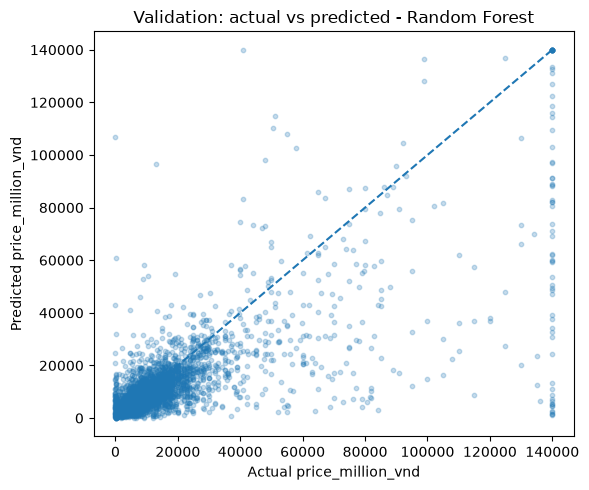

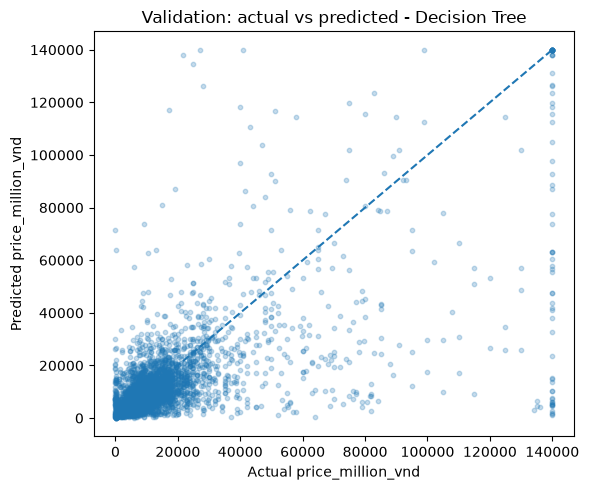

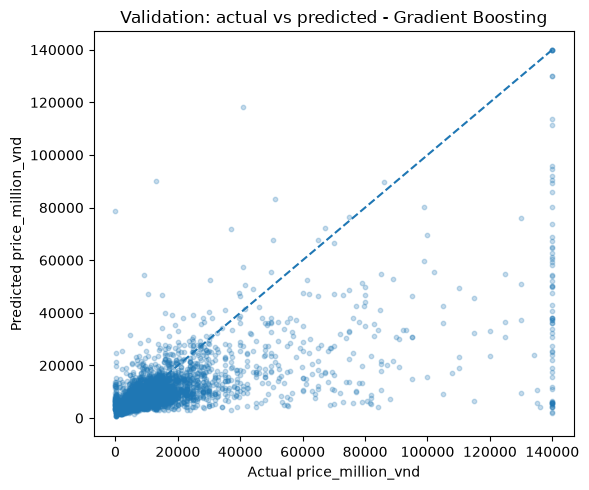

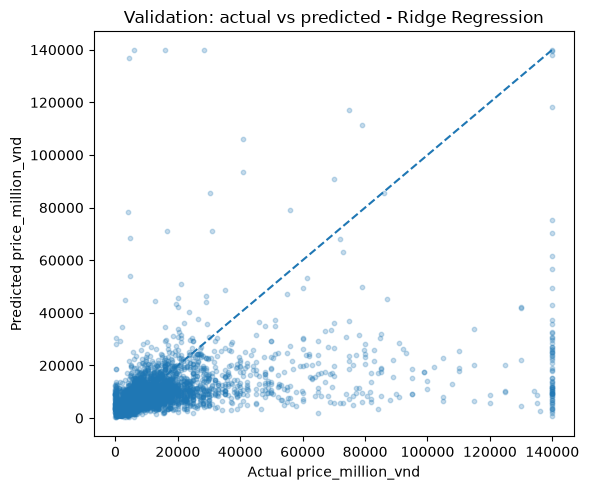

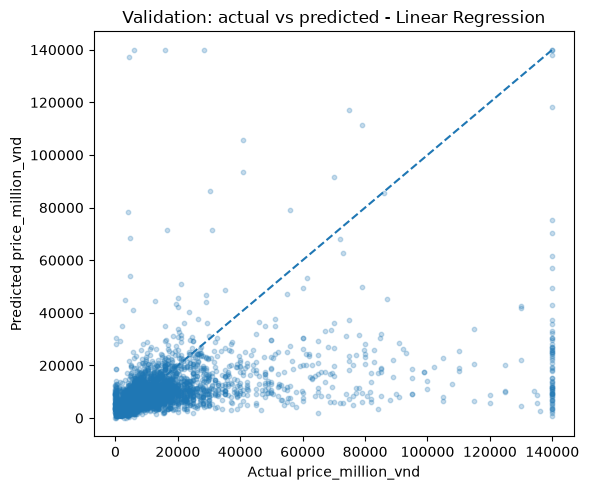

In [28]:
# 8.2 Actual vs predicted on validation for every model
# Cell nay: ve bieu do gia that vs gia du doan tren validation.
# Gioi han so diem ve (toi da 6000).
plot_sample_size = min(6000, len(X_val))
# Chon ngau nhien cac chi so de ve, co dinh seed.
plot_idx = np.random.RandomState(RANDOM_SEED).choice(
    len(X_val),
    size=plot_sample_size,
    replace=False,
)

# Chuyen y_val thanh mang numpy.
y_val_array = y_val.to_numpy()

# Ve cho tung mo hinh.
for name in validation_results.index:
    # Du doan cua mo hinh.
    pred = validation_predictions[name]

    # Clip only the displayed axes at the 99th percentile; metrics remain on full data.
    # Cap hien thi tai phan vi 99% cua gia that...
    cap_true = np.quantile(y_val_array, 0.99)
    # ...va cua gia du doan.
    cap_pred = np.quantile(pred, 0.99)
    # Lay cap lon hon de khong cat mat du lieu.
    cap = max(cap_true, cap_pred)

    # Tao khung ve.
    plt.figure(figsize=(6, 5))
    # Ve scatter gia that (truc X) vs gia du doan (truc Y).
    plt.scatter(
        # np.clip: gioi han gia tri hien thi trong [0, cap].
        np.clip(y_val_array[plot_idx], 0, cap),
        # Gioi han du doan hien thi.
        np.clip(pred[plot_idx], 0, cap),
        alpha=0.25,
        s=10,
    )
    # Duong cheo ly tuong: diem nam tren duong nay la du doan chuan.
    plt.plot([0, cap], [0, cap], linestyle="--")
    # Nhan truc X.
    plt.xlabel("Actual price_million_vnd")
    # Nhan truc Y.
    plt.ylabel("Predicted price_million_vnd")
    # Tieu de gom ten mo hinh.
    plt.title(f"Validation: actual vs predicted - {name}")
    # Dan bo cuc.
    plt.tight_layout()
    # Hien thi bieu do.
    plt.show()

# PART IX - MODEL COMPARISON AND FINAL MODEL SELECTION

Notebook chọn mô hình có **RMSE validation thấp nhất**, dùng `MAE` làm tiêu chí phụ.

Sau khi chọn, mô hình được refit trên `train + validation`, sau đó đánh giá đúng một lần trên test.

In [29]:
# 9.1 Select best model and refit on train+validation
# Cell nay: chon mo hinh tot nhat theo RMSE validation roi refit tren train+validation.
# Tieu chi chinh: RMSE.
PRIMARY_METRIC = "RMSE"
# Mo hinh dung dau bang xep hang (RMSE thap nhat).
best_model_name = validation_results.index[0]

# In ten mo hinh duoc chon.
print("Selected model:", best_model_name)
# Hien thi metrics validation cua mo hinh.
display(validation_results.loc[[best_model_name]])

# Gop train + validation.
X_trainval = pd.concat([X_train, X_val], axis=0)
# Gop nhan tuong ung.
y_trainval = pd.concat([y_train, y_val], axis=0)

# Tao estimator cuoi cung cho mo hinh duoc chon.
final_estimator = make_regression_estimator(REGRESSORS[best_model_name])

# Ghi thoi diem bat dau.
start = time.perf_counter()
# Refit tren toan bo train + validation.
final_estimator.fit(X_trainval, y_trainval)
# Tinh thoi gian refit.
final_refit_seconds = time.perf_counter() - start

# Du doan tren test - dung mot lan duy nhat.
y_test_pred = final_estimator.predict(X_test)
# Tinh metrics test.
test_scores = regression_scores(y_test, y_test_pred)

# Tao bang ket qua test.
test_result = pd.DataFrame(
    [{**test_scores, "Model": best_model_name, "Refit_seconds": final_refit_seconds}]
).set_index("Model")

# Hien thi ket qua test.
display(test_result)

Selected model: Random Forest


,MAE,MSE,RMSE,R2,Train_seconds
Model,,,,,
Random Forest,6547.863161,1.031277e+09,32113.495624,0.31462,20.151294


,MAE,MSE,RMSE,R2,Refit_seconds
Model,,,,,
Random Forest,6303.078144,1.059148e+09,32544.546661,0.18175,37.1087


,metric,value
0,median_abs_error,1645.225079
1,p90_abs_error,10391.344551
2,p95_abs_error,18165.139673
3,p99_abs_error,75605.778267
4,mean_residual,3507.601626


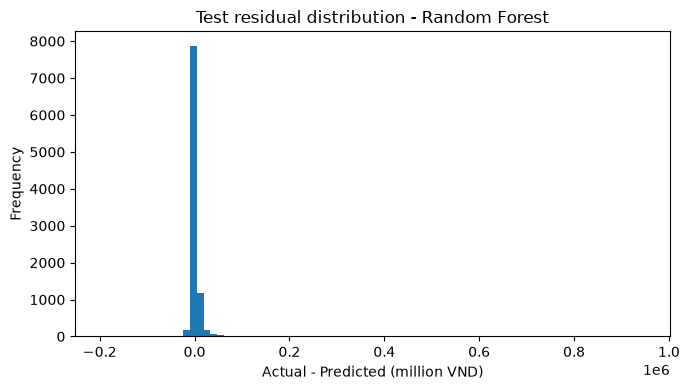

In [30]:
# 9.2 Final test residual analysis
# Cell nay: phan tich phan du tren test.
# residual: gia that - gia du doan.
residual = y_test.to_numpy() - y_test_pred
# Sai so tuyet doi.
abs_error = np.abs(residual)

# Tao bang tom tat loi: median, P90, P95, P99 va trung binh residual.
error_summary = pd.DataFrame(
    {
        "metric": [
            "median_abs_error",
            "p90_abs_error",
            "p95_abs_error",
            "p99_abs_error",
            "mean_residual",
        ],
        "value": [
            np.median(abs_error),
            np.quantile(abs_error, 0.90),
            np.quantile(abs_error, 0.95),
            np.quantile(abs_error, 0.99),
            np.mean(residual),
        ],
    }
)
# Hien thi bang.
display(error_summary)

# Tao khung ve.
plt.figure(figsize=(7, 4))
# Bieu do phan bo cua residual (80 cot).
plt.hist(residual, bins=80)
# Tieu de.
plt.title(f"Test residual distribution - {best_model_name}")
# Nhan truc X.
plt.xlabel("Actual - Predicted (million VND)")
# Nhan truc Y.
plt.ylabel("Frequency")
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

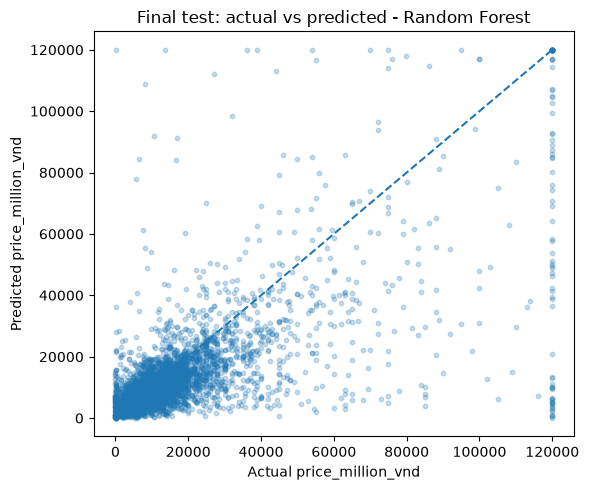

Largest absolute errors:


,location,area_m2,bedrooms,bathrooms,floors,frontage,actual_price,predicted_price,absolute_error,absolute_percentage_error
49190,"Vĩnh Cửu, Đồng Nai",NaN,2.0,2.0,NaN,0,950000.0,4859.039415,945140.960585,99.488522
42096,"Vĩnh Cửu, Đồng Nai",NaN,4.0,2.0,NaN,0,920000.0,135.007029,919864.992971,99.985325
48819,"Bình Tân, Hồ Chí Minh",NaN,NaN,3.0,4.0,0,930000.0,11238.992673,918761.007327,98.791506
49662,"Biên Hòa, Đồng Nai",NaN,2.0,2.0,1.0,0,820000.0,2546.614205,817453.385795,99.689437
11879,"Phú Nhuận, Hồ Chí Minh",NaN,2.0,2.0,4.0,0,795000.0,3450.755096,791549.244904,99.565943
35417,"Hà Đông, Hà Nội",40.0,NaN,NaN,4.0,0,735000.0,5060.788835,729939.211165,99.311457
4055,"Thanh Xuân, Hà Nội",30.0,4.0,3.0,5.0,0,728000.0,6607.874541,721392.125459,99.092325
21586,"Tây Hồ, Hà Nội",34.0,3.0,4.0,6.0,0,730000.0,10020.423087,719979.576913,98.627339
15431,"Bình Thạnh, Hồ Chí Minh",NaN,NaN,4.0,5.0,0,628000.0,4987.048697,623012.951303,99.205884
45450,"Đức Hòa, Long An",NaN,2.0,2.0,NaN,0,600000.0,1033.884783,598966.115217,99.827686


In [31]:
# 9.3 Final actual vs predicted and largest errors
# Cell nay: bieu do gia that vs du doan cuoi cung va xem cac loi lon nhat.
# Cap hien thi la phan vi 99% lon hon giua that va du doan.
cap = max(
    np.quantile(y_test.to_numpy(), 0.99),
    np.quantile(y_test_pred, 0.99),
)

# Gioi han so diem ve.
sample_size = min(8000, len(X_test))
# Chon ngau nhien chi so de ve, co dinh seed.
sample_idx = np.random.RandomState(RANDOM_SEED).choice(
    len(X_test),
    size=sample_size,
    replace=False,
)

# Tao khung ve.
plt.figure(figsize=(6, 5))
# Ve scatter gia that vs du doan.
plt.scatter(
    np.clip(y_test.to_numpy()[sample_idx], 0, cap),
    np.clip(y_test_pred[sample_idx], 0, cap),
    alpha=0.25,
    s=10,
)
# Duong cheo ly tuong.
plt.plot([0, cap], [0, cap], linestyle="--")
# Nhan truc X.
plt.xlabel("Actual price_million_vnd")
# Nhan truc Y.
plt.ylabel("Predicted price_million_vnd")
# Tieu de.
plt.title(f"Final test: actual vs predicted - {best_model_name}")
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

# error_df: ban sao X_test de gan cot loi.
error_df = X_test.copy()
# Cot gia that.
error_df["actual_price"] = y_test.values
# Cot gia du doan.
error_df["predicted_price"] = y_test_pred
# Cot sai so tuyet doi.
error_df["absolute_error"] = np.abs(error_df["actual_price"] - error_df["predicted_price"])
# Cot sai so phan tram tuyet doi.
error_df["absolute_percentage_error"] = error_df["absolute_error"] / error_df["actual_price"] * 100

# In tieu de cac loi lon nhat.
print("Largest absolute errors:")
# Hien thi 20 dong co sai so lon nhat.
display(error_df.sort_values("absolute_error", ascending=False).head(20))

# PART X - MODEL PERSISTENCE AND INFERENCE TEST

Lưu **toàn bộ estimator** gồm:
- train-fitted imputer;
- `RobustScaler`;
- `OneHotEncoder`;
- selected regression model;
- `log1p/expm1` target transformation.

Inference sau khi reload phải cho cùng kết quả.

In [32]:
# 10.1 Persist final estimator, preprocessor, fitted base model and metadata
# Cell nay: luu estimator cuoi, preprocessor, model va metadata.
# Duong dan thu muc model.
MODEL_DIR = Path("../model")
# Tao thu muc neu chua co.
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# File luu estimator hoan chinh.
PIPELINE_PATH = MODEL_DIR / "house_price_pipeline.joblib"
# File luu preprocessor.
PREPROCESSOR_PATH = MODEL_DIR / "house_price_preprocessor.joblib"
# File luu mo hinh goc.
MODEL_PATH = MODEL_DIR / "house_price_model.joblib"
# File metadata.
METADATA_PATH = MODEL_DIR / "house_price_metadata.json"

# TransformedTargetRegressor -> fitted regressor_ -> Pipeline
# TransformedTargetRegressor luu pipeline trong regressor_; lay preprocessor da fit.
final_preprocessor = final_estimator.regressor_.named_steps["preprocessor"]
# Lay mo hinh da fit.
final_model = final_estimator.regressor_.named_steps["model"]

# Ghi estimator hoan chinh ra dia.
joblib.dump(final_estimator, PIPELINE_PATH)
# Ghi rieng preprocessor.
joblib.dump(final_preprocessor, PREPROCESSOR_PATH)
# Ghi rieng mo hinh.
joblib.dump(final_model, MODEL_PATH)

# Ten feature cuoi cung.
final_feature_names = final_preprocessor.get_feature_names_out()
# Bien doi X_test de ghi shape vao metadata.
final_test_input = final_preprocessor.transform(X_test)

# Tao metadata.
metadata = {
    "application": "House-Price Prediction",
    "primary_dataset": DISPLAY_NAMES[PRIMARY_KEY],
    "target": TARGET,
    # Don vi cua target.
    "target_unit": "million VND",
    "random_seed": RANDOM_SEED,
    "raw_dataframe_shape": list(house_raw.shape),
    "clean_dataframe_shape": list(house_clean.shape),
    # Danh sach feature dau vao.
    "raw_input_features": X.columns.tolist(),
    "final_feature_dimension": int(len(final_feature_names)),
    "final_test_model_input_shape": list(final_test_input.shape),
    # Ten mo hinh duoc chon.
    "selected_model": best_model_name,
    "validation_primary_metric": PRIMARY_METRIC,
    # Metrics test cua mo hinh cuoi.
    "test_metrics": {k: float(v) for k, v in test_scores.items()},
    "dropped_columns": IRRELEVANT_COLUMNS,
    "domain_bounds": DOMAIN_BOUNDS,
    # Ghi ro phep bien doi target.
    "target_transform": "log1p during fit; expm1 during prediction",
}

# Mo file metadata de ghi.
with open(METADATA_PATH, "w", encoding="utf-8") as f:
    # Ghi JSON voi Unicode giu nguyen.
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# In duong dan cac file da luu.
print("Saved full pipeline:", PIPELINE_PATH.resolve())
# In duong dan preprocessor.
print("Saved preprocessor:", PREPROCESSOR_PATH.resolve())
# In duong dan mo hinh.
print("Saved fitted base model:", MODEL_PATH.resolve())
# In duong dan metadata.
print("Saved metadata:", METADATA_PATH.resolve())
# In shape dau vao tren test.
print("Final model-input shape on test:", final_test_input.shape)
# In so chieu feature.
print("Final feature dimension d:", len(final_feature_names))

Saved full pipeline: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\house_price\model\house_price_pipeline.joblib
Saved preprocessor: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\house_price\model\house_price_preprocessor.joblib
Saved fitted base model: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\house_price\model\house_price_model.joblib
Saved metadata: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\house_price\model\house_price_metadata.json
Final model-input shape on test: (9668, 269)
Final feature dimension d: 269


In [33]:
# 10.2 Reload and inference consistency test
# Cell nay: kiem tra tinh nhat quan sau khi nap lai estimator.
# Nap lai estimator da luu.
reloaded_estimator = joblib.load(PIPELINE_PATH)

# 5 dong dau X_test lam mau.
sample_input = X_test.head(5).copy()
# Du doan truoc khi luu.
pred_before = final_estimator.predict(sample_input)
# Du doan sau khi nap lai.
pred_after = reloaded_estimator.predict(sample_input)

# In tieu de du lieu mau.
print("Sample raw input:")
# Hien thi du lieu mau.
display(sample_input)

# Tao bang so sanh du doan truoc/sau.
comparison = pd.DataFrame(
    {
        "prediction_before_save": pred_before,
        "prediction_after_reload": pred_after,
        # Cot chenh lech tuyet doi giua 2 lan du doan.
        "difference": np.abs(pred_before - pred_after),
    }
)
# Hien thi bang so sanh.
display(comparison)

# In ket qua kiem tra bang nhau bang np.allclose.
print(
    "Predictions numerically identical:",
    bool(np.allclose(pred_before, pred_after, rtol=0, atol=1e-10)),
)

Sample raw input:


,location,area_m2,bedrooms,bathrooms,floors,frontage
59892,"Nha Trang, Khánh Hòa",159.0,NaN,NaN,NaN,0
26093,"Bình Tân, Hồ Chí Minh",72.0,5.0,5.0,3.0,0
57990,"Thủ Đức, Hồ Chí Minh",88.0,2.0,2.0,2.0,0
902,"Thủ Đức, Hồ Chí Minh",132.0,3.0,3.0,3.0,0
27579,"Tân Phú, Hồ Chí Minh",80.0,2.0,1.0,3.0,1


,prediction_before_save,prediction_after_reload,difference
0,4946.770278,4946.770278,9.094947e-12
1,6597.701921,6597.701921,0.000000e+00
2,5658.988252,5658.988252,1.000444e-11
3,5395.146058,5395.146058,1.000444e-11
4,11503.038303,11503.038303,2.000888e-11


Predictions numerically identical: True


In [34]:
# 10.3 Final evidence table for report
# Cell nay: tao bang bang chung cuoi cung cho bao cao.
# Bang liet ke chi so quan trong.
final_evidence = pd.DataFrame(
    {
        # Cot ten chi so.
        "Item": [
            "Raw dataframe shape",
            "Clean dataframe shape",
            # So dong train/validation/test.
            "Train rows",
            "Validation rows",
            "Test rows",
            "Raw input features",
            "Final numerical feature dimension",
            # Ten mo hinh duoc chon.
            "Selected model",
            # Ten cac file da luu.
            "Full pipeline file",
            "Preprocessor file",
            "Model file",
        ],
        # Cot gia tri.
        "Value": [
            # Shape du lieu tho.
            str(house_raw.shape),
            str(house_clean.shape),
            len(X_train),
            len(X_val),
            len(X_test),
            X.shape[1],
            # So chieu feature cuoi.
            len(final_feature_names),
            best_model_name,
            # Duong dan file pipeline.
            str(PIPELINE_PATH),
            str(PREPROCESSOR_PATH),
            str(MODEL_PATH),
        ],
    }
)
# Hien thi bang bang chung.
display(final_evidence)
# Hien thi lai ket qua test.
display(test_result)

,Item,Value
0,Raw dataframe shape,"(66912, 11)"
1,Clean dataframe shape,"(64447, 7)"
2,Train rows,45112
3,Validation rows,9667
4,Test rows,9668
5,Raw input features,6
6,Final numerical feature dimension,269
7,Selected model,Random Forest
8,Full pipeline file,..\model\house_price_pipeline.joblib
9,Preprocessor file,..\model\house_price_preprocessor.joblib


,MAE,MSE,RMSE,R2,Refit_seconds
Model,,,,,
Random Forest,6303.078144,1.059148e+09,32544.546661,0.18175,37.1087
